<a href="https://colab.research.google.com/github/eyalab1/Sawtooth-to-Cello/blob/main/Saw_To_Cello.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sawtooth-to-Cello: Neural Audio Synthesis with U-Net and HiFi-GAN

This notebook implements a complete pipeline for transforming simple **sawtooth waveforms** into realistic **cello sounds** using deep learning.

## Pipeline Overview

1. **Input Synthesis**: MIDI notes are converted to sawtooth waves (simple, harmonically rich signals)
2. **Mel Spectrogram**: Both sawtooth and cello audio are converted to mel spectrograms
3. **U-Net Transformation**: A U-Net learns to map sawtooth mel spectrograms to cello mel spectrograms
4. **HiFi-GAN Vocoder**: The predicted cello mel spectrogram is converted back to audio using HiFi-GAN

## Architecture

- **U-Net** with residual blocks, skip connections, and dropout for mel-to-mel transformation
- **PatchGAN Discriminator** for adversarial training (sharper, more realistic spectrograms)
- **HiFi-GAN** (pre-trained, then fine-tuned on cello) as the neural vocoder
- **MAESTRO Dataset** (classical piano MIDI) as the source of musical phrases

## Key Techniques

- Melody extraction (monophonic) from polyphonic MIDI for cleaner cello synthesis
- Adversarial training (L1 + GAN loss) for sharper mel predictions
- Overlap-add inference with Hann windowing for seamless long-form generation
- HiFi-GAN fine-tuning on cello audio for domain-specific vocoding
- Pre-rendered mel spectrograms saved to Google Drive for efficient training


## Abstract

This work presents a deep learning pipeline for **timbre transfer**: converting the spectral character of a synthetic sawtooth waveform into that of a realistic cello, while preserving the original melody, timing, and pitch. The system combines a **U-Net** mel-spectrogram-to-mel-spectrogram translator with a **HiFi-GAN** neural vocoder fine-tuned on cello audio, trained adversarially using a **PatchGAN discriminator**. Training data is derived from the MAESTRO v3.0.0 classical piano MIDI corpus, rendered through FluidSynth with a cello SoundFont as supervision targets. Quantitative evaluation uses Mel Cepstral Distortion (MCD), Perceptual Evaluation of Speech Quality (PESQ), and Scale-Invariant Signal-to-Distortion Ratio (SI-SDR) on a held-out validation set.

---

## 1. Introduction

The synthesis of realistic musical instrument sounds from simplified input signals is a long-standing challenge in music information retrieval and audio deep learning. Classical digital signal processing approaches -- wavetable synthesis, physical modelling, FM synthesis -- can approximate instrument timbres but require extensive hand-crafting of acoustic parameters. Data-driven timbre transfer sidesteps this by learning the mapping directly from paired audio examples.

**Motivation.** The cello is a particularly demanding target: its sound is shaped by complex interactions between bow pressure, string resonance, the wooden body cavity, and vibrato, producing a rich, time-varying harmonic envelope that is difficult to model analytically. A sawtooth wave, by contrast, shares the same harmonic series (all integer multiples of the fundamental) but with uniform amplitude decay, making it a natural, controlled input from which the model must learn to hallucinate the acoustic differences.

**Problem Statement.** Given a melody sequence of MIDI notes, our goal is to produce audio output that:
1. Preserves the pitch trajectory and note timing of the original sequence.
2. Exhibits the timbre, dynamics, and spectral envelope of a bowed cello.
3. Is perceptually indistinguishable from FluidSynth-rendered cello at the vocoder output.

**Contributions.**
- A complete, reproducible pipeline from MIDI to cello-like audio, runnable in Google Colab with no local hardware requirements.
- A U-Net architecture with skip connections and progressive dropout trained with combined L1 + adversarial loss on pre-rendered mel spectrogram pairs.
- Domain-specific fine-tuning of HiFi-GAN on cello audio using multi-resolution spectral loss.
- Overlap-add inference enabling generation of arbitrarily long musical sequences.
- Quantitative benchmarking on a held-out MAESTRO validation split using MCD, PESQ, and SI-SDR.


## 1. Environment Setup

Install the system-level audio engine (FluidSynth) and all required Python libraries.

- **FluidSynth**: Software synthesizer that renders MIDI to audio using SoundFont files
- **pretty_midi**: MIDI file parsing and manipulation
- **librosa**: Audio feature extraction (mel spectrograms)
- **soundfile/pyfluidsynth**: Audio I/O and FluidSynth Python bindings


## 2. Theoretical Background

### 2.1 Mel Spectrogram Representation

A mel spectrogram represents audio as a 2-D time-frequency image where the frequency axis is warped to the **mel scale**, which approximates the non-linear frequency resolution of the human auditory system (O'Shaughnessy, 1987). Formally, for a signal $x(t)$ sampled at $f_s$, the mel spectrogram $M \in \mathbb{R}^{F \times T}$ is computed by:

$$M = \log\left(\mathbf{W}_{\text{mel}} \cdot |\text{STFT}(x)|^2 + \epsilon\right)$$

where $\mathbf{W}_{\text{mel}} \in \mathbb{R}^{F \times N_{\text{fft}}/2}$ is a triangular filterbank matrix with $F=80$ mel bins, and $\epsilon$ prevents numerical underflow. The HiFi-GAN vocoder requires this exact parameterisation (1024-point FFT, hop size 256, window size 1024), so all mel computations in this project use the same settings for consistency.

### 2.2 U-Net for Spectrogram Transformation

The **U-Net** (Ronneberger et al., 2015), originally proposed for biomedical image segmentation, has proven highly effective for audio-domain spectrogram translation tasks (Jansson et al., 2017; Stoller et al., 2018). The architecture consists of a symmetric encoder-decoder with **skip connections** that bypass compressed representations directly to corresponding decoder layers.

In this project the U-Net operates on mel spectrograms as single-channel 2-D images:
- **Encoder**: 3 downsampling stages (64 -> 128 -> 256 -> 512 channels) with residual blocks and strided convolutions.
- **Bottleneck**: 2 residual blocks with 30% dropout to reduce overfitting.
- **Decoder**: 3 upsampling stages (bilinear + conv) with skip-connection concatenation.
- **Output**: Predicted cello mel spectrogram $\hat{M}_{\text{cello}} \in \mathbb{R}^{80 \times 128}$.

Skip connections are critical: without them, the decoder must reconstruct fine-grained pitch and onset information from a heavily compressed bottleneck representation, causing spectral blurring.

### 2.3 Generative Adversarial Training with PatchGAN

Pure L1 regression on mel spectrograms tends to produce over-smoothed predictions (Isola et al., 2017), because L1 minimises the conditional mean rather than sampling from the true conditional distribution. Adversarial training (Goodfellow et al., 2014) augments L1 with a discriminator $D$ that provides a perceptual sharpness signal.

We use a **PatchGAN discriminator** (Isola et al., 2017), which classifies overlapping $N \times N$ patches of the spectrogram as real or fake rather than the entire image. This forces the generator to produce locally coherent spectral textures and is computationally cheaper than a full-image discriminator. The combined generator loss is:

$$\mathcal{L}_G = \lambda_{L1} \cdot \|\hat{M} - M_{\text{target}}\|_1 + \lambda_{\text{adv}} \cdot \mathcal{L}_{\text{GAN}}(\hat{M})$$

with $\lambda_{L1} = 100$ and $\lambda_{\text{adv}} = 1$, balancing structural accuracy against perceptual realism.

### 2.4 HiFi-GAN Neural Vocoder

**HiFi-GAN** (Kong et al., 2020) is a GAN-based vocoder that converts mel spectrograms to waveforms at high fidelity and real-time speed. Its generator uses a stack of transposed convolutions for upsampling combined with **Multi-Receptive Field Fusion (MRF)** -- parallel residual blocks with different dilation patterns that capture short- and long-range waveform structure simultaneously. The discriminator ensemble includes a **Multi-Period Discriminator (MPD)** and a **Multi-Scale Discriminator (MSD)** operating on waveform segments of varying periods and resolutions.

In this project we initialise from the pretrained `UNIVERSAL_V1` checkpoint and fine-tune on 500 cello audio clips using a multi-resolution mel loss over FFT scales {256, 512, 1024}, adapting the vocoder's spectral biases from speech to the cello's lower fundamental frequency range (~65-700 Hz).

### 2.5 Related Work

| Work | Input | Target | Method |
|------|-------|--------|--------|
| Jansson et al. (2017) | Mixture spectrogram | Vocals | U-Net (frequency masking) |
| Mor et al. (2019) | Any instrument | Any instrument | Unsupervised domain translation |
| Engel et al. (2020) -- DDSP | Pitch + loudness | Violin/flute | Differentiable DSP |
| **This work** | Sawtooth (supervised) | Cello | U-Net + HiFi-GAN + PatchGAN |

Our approach differs from DDSP (Engel et al., 2020) in that it operates entirely in the mel spectrogram domain without explicit DSP components, and from unsupervised domain translation in that it uses paired sawtooth/cello examples for a more stable, controllable training signal.


In [ ]:
# @title 1. Install System Dependencies & Libraries
import os
import sys

print("Installing FluidSynth (Audio Engine)...")
!apt-get install -y fluidsynth > /dev/null

print("Installing Python Libraries...")
!pip install -q pyfluidsynth pretty_midi librosa soundfile matplotlib

print("Done.")

Installing FluidSynth (Audio Engine)...
Extracting templates from packages: 100%
Installing Python Libraries...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 74.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 6.4 MB/s eta 0:00:00
Done.


## 2. Mount Google Drive

Connect Google Drive to persist all checkpoints, pre-rendered data, and model weights across sessions.
All project files are saved under `/content/drive/MyDrive/CelloProject/`.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


import os
SAVE_DIR = '/content/drive/MyDrive/CelloProject'
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"✅ Google Drive מחובר!")
print(f"📂 הקבצים יישמרו ב: {SAVE_DIR}")

Mounted at /content/drive
✅ Google Drive מחובר!
📂 הקבצים יישמרו ב: /content/drive/MyDrive/CelloProject


## 3. Download SoundFont (Cello Instrument)

Download the **FluidR3 General MIDI SoundFont** -- a collection of sampled instruments.
We use program 42 (Cello) from this SoundFont to generate our **target audio** via FluidSynth.
This gives us realistic cello recordings that the model will learn to imitate.


In [ ]:
# @title 2. Download SoundFont (Cello Instrument)
sf2_path = 'FluidR3_GM.sf2'

if not os.path.exists(sf2_path):
    print("Downloading SoundFont...")
    !wget -q https://keymusician01.s3.amazonaws.com/FluidR3_GM.zip
    !unzip -q FluidR3_GM.zip
    print("SoundFont downloaded and extracted.")
else:
    print("SoundFont already exists.")

unzip:  cannot find or open FluidR3_GM.zip, FluidR3_GM.zip.zip or FluidR3_GM.zip.ZIP.
SoundFont downloaded and extracted.


## 4. Clone HiFi-GAN Repository & Download Pretrained Weights

[HiFi-GAN](https://github.com/jik876/hifi-gan) is a state-of-the-art neural vocoder that converts mel spectrograms to audio.
We use the **UNIVERSAL_V1** pretrained checkpoint as our starting point.

The vocoder serves as the final stage of our pipeline: after the U-Net predicts a cello-like mel spectrogram,
HiFi-GAN synthesizes the actual waveform from it.


In [ ]:
# CELL 2 — Get HiFi-GAN repo + pretrained models (UNIVERSAL_V1)

import os, shutil

# Clone repo if missing
if not os.path.exists("/content/hifi-gan"):
    !git clone -q https://github.com/jik876/hifi-gan.git /content/hifi-gan
else:
    print("✅ /content/hifi-gan already exists")

# Download pretrained folder (Google Drive)
%cd /content/hifi-gan
if not os.path.exists("/content/hifi-gan/pretrained"):
    !gdown --folder "https://drive.google.com/drive/folders/1-eEYTB5Av9jNql0WGBlRoi-WH2J7bp5Y" -O pretrained
else:
    print("✅ pretrained/ already exists")

# Quick verify
!ls -la
!find pretrained -maxdepth 3 -type f -name "g_*" | head -n 20


/content/hifi-gan
Retrieving folder contents
Retrieving folder 1dqpUYEYF_hH7T0rII9_VQbps45FvNBqf LJ_FT_T2_V1
Processing file 1l5EUVBKM0SK7ec4HWf_wZvEITAsdOLFC config.json
Processing file 1QEBKespXTmsMzsSRBXWdpIT0Ve7nnaRZ generator_v1
Retrieving folder 1_N-GLoMn1tu4kqXJ9XsuCm1GmhQFzSxG LJ_FT_T2_V2
Processing file 11LnhSum3EAeo5zag-tpU8HKk0MdbrQxF config.json
Processing file 1I415g2Cdx5FWy6ECma0zEc9GhX_TnbFv generator_v2
Retrieving folder 1nXBaw4tMKJyiIVtU0eXWoAzXLOOMFiaX LJ_FT_T2_V3
Processing file 1mke75axgO2sdJ41GL2HTrcb4KyAl0i45 config.json
Processing file 1fnkOteyRdPq4Gh2cfso3gqqrC6inLWsF generator_v3
Retrieving folder 1XtZ_AaYIsnx1zh_HxhrG5SZ6MUJV59gm LJ_V1
Processing file 1aDh576AEYA5eTjhx7sew1qcCM_Y526jc config.json
Processing file 14NENd4equCBLyyCSke114Mv6YR_j_uFs generator_v1
Retrieving folder 1bB1tnGIxRN-edlf6k2Rmi1gNCK9Cpcvf LJ_V2
Processing file 1vxXvAdsCtAk8jbYBxAd7KANeqNPVtsTW config.json
Processing file 1gfouaWecMbmfqIdWYs-KtsULIdYCveYW generator_v2
Retrieving folder 1KKv

## 5. Create Modular Project Structure

Save the core model architectures and dataset classes as standalone Python files in Google Drive.
This creates a reusable project structure:

- **`models.py`**: AudioUNet (generator) and PatchDiscriminator (for adversarial training)
- **`dataset.py`**: PyTorch Dataset class for loading pre-rendered mel spectrogram pairs
- **`requirements.txt`**: Project dependencies

These files mirror the architectures defined later in this notebook, providing a clean codebase for deployment.


In [ ]:
import os

# Define the target directory in Google Drive
PROJECT_DIR = '/content/drive/MyDrive/CelloProject'
SRC_DIR = os.path.join(PROJECT_DIR, 'src')
os.makedirs(SRC_DIR, exist_ok=True)

print(f"Creating modular Python files in: {SRC_DIR}...")

# ==========================================
# 1. models.py (U-Net and Discriminator)
# ==========================================
models_code = """import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return F.relu(x + residual)

class DownSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class UpSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = nn.ReLU()

    def forward(self, x):
        return self.act(self.bn(self.up(x)))

class AudioUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=3, padding=1), ResidualBlock(64))
        self.down1 = DownSample(64, 128)
        self.enc2 = ResidualBlock(128)
        self.down2 = DownSample(128, 256)
        self.enc3 = ResidualBlock(256)
        self.down3 = DownSample(256, 512)

        self.bottleneck = nn.Sequential(
            ResidualBlock(512), nn.Dropout2d(0.3), ResidualBlock(512)
        )

        self.up3 = UpSample(512, 256)
        self.dec3 = nn.Sequential(ResidualBlock(512), nn.Dropout2d(0.2))
        self.up2 = UpSample(512, 128)
        self.dec2 = nn.Sequential(ResidualBlock(256), nn.Dropout2d(0.1))
        self.up1 = UpSample(256, 64)
        self.dec1 = ResidualBlock(128)
        self.final = nn.Conv2d(128, 1, kernel_size=3, padding=1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.down1(x1))
        x3 = self.enc3(self.down2(x2))
        neck = self.bottleneck(self.down3(x3))

        u3 = self.up3(neck)
        if u3.shape[2:] != x3.shape[2:]: u3 = F.interpolate(u3, size=x3.shape[2:])
        d3 = self.dec3(torch.cat([u3, x3], dim=1))

        u2 = self.up2(d3)
        if u2.shape[2:] != x2.shape[2:]: u2 = F.interpolate(u2, size=x2.shape[2:])
        d2 = self.dec2(torch.cat([u2, x2], dim=1))

        u1 = self.up1(d2)
        if u1.shape[2:] != x1.shape[2:]: u1 = F.interpolate(u1, size=x1.shape[2:])
        d1 = self.dec1(torch.cat([u1, x1], dim=1))

        return self.final(d1)

class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=2):
        super().__init__()
        def disc_block(in_ch, out_ch, stride=2):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=stride, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.LeakyReLU(0.2, inplace=True)
            )
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            disc_block(64, 128, stride=2),
            disc_block(128, 256, stride=2),
            disc_block(256, 512, stride=1),
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1)
        )

    def forward(self, input_mel, target_or_pred_mel):
        x = torch.cat([input_mel, target_or_pred_mel], dim=1)
        return self.model(x)
"""
with open(os.path.join(SRC_DIR, 'models.py'), 'w') as f:
    f.write(models_code)
print("✅ Created models.py")

# ==========================================
# 2. dataset.py (Data Loading)
# ==========================================
dataset_code = """import os, glob
import torch
from torch.utils.data import Dataset

class PrerenderedMelDataset(Dataset):
    def __init__(self, data_dir, augment=False):
        self.data_files = glob.glob(os.path.join(data_dir, "*.pt"))
        self.augment = augment
        if len(self.data_files) == 0:
            print(f"Warning: No .pt files found in {data_dir}")

    def __len__(self):
        return len(self.data_files)

    def __getitem__(self, idx):
        mel_in, mel_tg = torch.load(self.data_files[idx])
        if self.augment:
            gain = torch.empty(1).uniform_(0.8, 1.2).item()
            mel_in = mel_in * gain
            if torch.rand(1).item() < 0.5:
                noise_level = torch.empty(1).uniform_(0.0, 0.02).item()
                mel_in = mel_in + noise_level * torch.randn_like(mel_in)
        return mel_in, mel_tg
"""
with open(os.path.join(SRC_DIR, 'dataset.py'), 'w') as f:
    f.write(dataset_code)
print("✅ Created dataset.py")

# ==========================================
# 3. requirements.txt
# ==========================================
reqs_code = """torch
numpy
scipy
librosa
pretty_midi
matplotlib
"""
with open(os.path.join(SRC_DIR, 'requirements.txt'), 'w') as f:
    f.write(reqs_code)
print("✅ Created requirements.txt")

print("\n🎉 Modular project structure is ready in your Google Drive!")
print(f"Directory: {SRC_DIR}")


Creating modular Python files in: /content/drive/MyDrive/CelloProject/src...
✅ Created models.py
✅ Created dataset.py
✅ Created requirements.txt

🎉 Modular project structure is ready in your Google Drive!
Directory: /content/drive/MyDrive/CelloProject/src


## 6. Verify / Re-download HiFi-GAN Pretrained Models

Ensure the pretrained HiFi-GAN weights are correctly downloaded.
This cell does a clean re-download if needed, removing any corrupted files from previous attempts.


In [ ]:
# @title download Pretrained Models
import os
import shutil

# Ensure we are in the correct directory
%cd /content/hifi-gan

# Remove existing pretrained folder if it exists to start fresh
if os.path.exists("pretrained"):
    print("Removing existing 'pretrained' directory...")
    shutil.rmtree("pretrained")

print("Downloading pretrained models...")
# Download the folder using gdown
!gdown --folder "https://drive.google.com/drive/folders/1-eEYTB5Av9jNql0WGBlRoi-WH2J7bp5Y" -O pretrained

print("Verifying download...")
!find pretrained -maxdepth 3 -type f -name "g_*" | head -n 20

/content/hifi-gan
Removing existing 'pretrained' directory...
Retrieving folder contents
Retrieving folder 1dqpUYEYF_hH7T0rII9_VQbps45FvNBqf LJ_FT_T2_V1
Processing file 1l5EUVBKM0SK7ec4HWf_wZvEITAsdOLFC config.json
Processing file 1QEBKespXTmsMzsSRBXWdpIT0Ve7nnaRZ generator_v1
Retrieving folder 1_N-GLoMn1tu4kqXJ9XsuCm1GmhQFzSxG LJ_FT_T2_V2
Processing file 11LnhSum3EAeo5zag-tpU8HKk0MdbrQxF config.json
Processing file 1I415g2Cdx5FWy6ECma0zEc9GhX_TnbFv generator_v2
Retrieving folder 1nXBaw4tMKJyiIVtU0eXWoAzXLOOMFiaX LJ_FT_T2_V3
Processing file 1mke75axgO2sdJ41GL2HTrcb4KyAl0i45 config.json
Processing file 1fnkOteyRdPq4Gh2cfso3gqqrC6inLWsF generator_v3
Retrieving folder 1XtZ_AaYIsnx1zh_HxhrG5SZ6MUJV59gm LJ_V1
Processing file 1aDh576AEYA5eTjhx7sew1qcCM_Y526jc config.json
Processing file 14NENd4equCBLyyCSke114Mv6YR_j_uFs generator_v1
Retrieving folder 1bB1tnGIxRN-edlf6k2Rmi1gNCK9Cpcvf LJ_V2
Processing file 1vxXvAdsCtAk8jbYBxAd7KANeqNPVtsTW config.json
Processing file 1gfouaWecMbmfqIdWYs-KtsUL

## 7. Patch HiFi-GAN Code & Load the Generator

The original HiFi-GAN codebase has compatibility issues with newer versions of PyTorch and librosa.
This cell applies two critical patches to `meldataset.py`:

1. **`torch.stft` fix**: Add `return_complex=False` (required since PyTorch 1.8+)
2. **`librosa.filters.mel` fix**: Use explicit `import librosa.filters` to avoid name collision

After patching, we load the UNIVERSAL_V1 generator checkpoint and freeze its weights.
The generator (`G`) and mel spectrogram function (`mel_spectrogram`) are now ready for use.


In [ ]:
# CELL 3 — Patch meldataset.py + load HiFi-GAN (G, h, mel_spectrogram)

import os, re, json, glob, importlib, sys
import torch

HIFIGAN_DIR = "/content/hifi-gan"
meldataset_path = os.path.join(HIFIGAN_DIR, "meldataset.py")
assert os.path.exists(meldataset_path), "❌ meldataset.py not found. Did you clone the repo?"

# --- Patch meldataset.py safely ---
txt = open(meldataset_path, "r", encoding="utf-8").read()

# Fix any broken hann_window key variants
txt = txt.replace("hann_window[str(y.device, return_complex=False)]", "hann_window[str(y.device)]")
txt = txt.replace("hann_window[str(y.device,return_complex=False)]", "hann_window[str(y.device)]")

# Ensure torch.stft has return_complex=False exactly once
lines = txt.splitlines()
out = []
inside = False
for line in lines:
    if "spec = torch.stft(" in line:
        inside = True
        out.append(line)
        continue
    if inside:
        if "return_complex" in line:
            # remove duplicates if present
            line = line.replace("return_complex=False, return_complex=False", "return_complex=False")
        if "onesided=True" in line and "return_complex" not in line:
            line = line.replace("onesided=True", "onesided=True, return_complex=False")
            inside = False
        out.append(line)
        # fallback: if call ended without onesided line
        if inside and line.strip().endswith(")"):
            # add before closing paren (rare)
            if "return_complex" not in line:
                out[-1] = out[-1][:-1] + ", return_complex=False)"
            inside = False
        continue
    out.append(line)

patched = "\n".join(out)

# Remove any remaining double return_complex in same line
patched = patched.replace("return_complex=False, return_complex=False", "return_complex=False")

# --- FIX: Ensure explicit librosa.filters.mel usage to avoid name collision ---
# Replace 'from librosa.filters import mel as librosa_mel_fn' with 'import librosa.filters'
# And then replace 'librosa_mel_fn(' with 'librosa.filters.mel('
modified_for_mel_fix = False
if "from librosa.filters import mel as librosa_mel_fn" in patched:
    patched = patched.replace("from librosa.filters import mel as librosa_mel_fn", "import librosa.filters")
    # Only replace if the previous one existed, to avoid altering unrelated text
    patched = patched.replace("mel = librosa_mel_fn(", "mel = librosa.filters.mel(")
    modified_for_mel_fix = True

if patched != txt:
    open(meldataset_path, "w", encoding="utf-8").write(patched)
    print("✅ Patched meldataset.py for torch.stft(return_complex=False)" + (" and explicit librosa.filters.mel usage" if modified_for_mel_fix else ""))
else:
    print("ℹ️ meldataset.py already looks patched")

# --- Import from repo (use repo's classes) ---
if HIFIGAN_DIR not in sys.path:
    sys.path.insert(0, HIFIGAN_DIR)

from env import AttrDict
from models import Generator

import meldataset
importlib.reload(meldataset)
from meldataset import mel_spectrogram

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(os.path.join(HIFIGAN_DIR, "config_v1.json"), "r") as f:
    h = AttrDict(json.load(f))

G = Generator(h).to(device)

# Find a UNIVERSAL_V1 checkpoint
cands = sorted(glob.glob(os.path.join(HIFIGAN_DIR, "pretrained/**/UNIVERSAL_V1/g_*"), recursive=True))
assert len(cands) > 0, "❌ No UNIVERSAL_V1 generator checkpoint found under pretrained/"

GEN_CKPT = cands[-1]
ckpt = torch.load(GEN_CKPT, map_location=device)
state = ckpt["generator"] if isinstance(ckpt, dict) and "generator" in ckpt else ckpt
G.load_state_dict(state, strict=True)

G.eval()
for p in G.parameters():
    p.requires_grad = False

print("✅ HiFi-GAN loaded:", GEN_CKPT)
print("✅ device:", device)

# quick show the stft line (sanity)
p = meldataset_path
with open(p, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, 1):
        if "spec = torch.stft" in line:
            print("torch.stft line:", i)
            print(line.strip())
            break

✅ Patched meldataset.py for torch.stft(return_complex=False) and explicit librosa.filters.mel usage


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


✅ HiFi-GAN loaded: /content/hifi-gan/pretrained/UNIVERSAL_V1/g_02500000
✅ device: cuda
torch.stft line: 64
spec = torch.stft(y, n_fft, hop_length=hop_size, win_length=win_size, window=hann_window[str(y.device)],


## 8. Additional Librosa Compatibility Patch

Apply a second patch to ensure `librosa.filters.mel()` is called with **keyword arguments**
instead of positional ones. Newer versions of librosa changed the parameter names,
so this ensures compatibility across all librosa versions.


In [ ]:
# FIX: patch meldataset.py to call librosa.filters.mel with keyword args (works on all librosa versions)

import os, re, importlib
import librosa

print("librosa version:", librosa.__version__)

path = "/content/hifi-gan/meldataset.py"
assert os.path.exists(path), "❌ /content/hifi-gan/meldataset.py not found"

txt = open(path, "r", encoding="utf-8").read()

# Replace the positional call with keyword call
txt2 = re.sub(
    r"librosa\.filters\.mel\(\s*sampling_rate\s*,\s*n_fft\s*,\s*num_mels\s*,\s*fmin\s*,\s*fmax\s*\)",
    "librosa.filters.mel(sr=sampling_rate, n_fft=n_fft, n_mels=num_mels, fmin=fmin, fmax=fmax)",
    txt
)

if txt2 == txt:
    print("ℹ️ Pattern not found (maybe already patched or different line). Trying a broader patch...")

    # broader: any mel( ... ) on that line
    txt2 = re.sub(
        r"librosa\.filters\.mel\((.*?)\)",
        "librosa.filters.mel(sr=sampling_rate, n_fft=n_fft, n_mels=num_mels, fmin=fmin, fmax=fmax)",
        txt,
        count=1
    )

open(path, "w", encoding="utf-8").write(txt2)
print("✅ patched:", path)

# Reload meldataset to apply patch
import meldataset
importlib.reload(meldataset)
from meldataset import mel_spectrogram
print("✅ meldataset reloaded, mel_spectrogram imported")


librosa version: 0.11.0
✅ patched: /content/hifi-gan/meldataset.py
✅ meldataset reloaded, mel_spectrogram imported


## 9. Sanity Test: FluidSynth Cello + HiFi-GAN Reconstruction

Before training anything, we verify that the **vocoder pipeline works correctly**:

1. Create a simple 5-note MIDI sequence (C-D-E-F-G)
2. Render it as cello audio using FluidSynth + SoundFont
3. Convert the cello audio to a mel spectrogram
4. Reconstruct audio from the mel using HiFi-GAN

If the reconstruction sounds close to the original, the vocoder is working and we can trust
that any mel spectrogram our U-Net produces will be faithfully converted to audio.

This cell also defines key helper functions used throughout the notebook:
- `prep_audio_np()`: Normalize audio to [-1, 1]
- `audio_to_mel_hifigan()`: Convert audio to HiFi-GAN-compatible mel spectrogram
- `vocode_mel()`: Convert mel spectrogram back to audio via HiFi-GAN


In [ ]:
# CELL 4 — Create a quick target via FluidSynth + RECON sanity test

import numpy as np
import pretty_midi
import os
from IPython.display import Audio, display

# FIX: Use absolute path for SoundFont because CWD might have changed to /content/hifi-gan
sf2_path = '/content/FluidR3_GM.sf2'

def prep_audio_np(x):
    x = np.asarray(x, dtype=np.float32)
    x = x / (np.max(np.abs(x)) + 1e-9)
    return np.clip(x, -1.0, 1.0)

@torch.no_grad()
def audio_to_mel_hifigan(audio_np):
    x = torch.from_numpy(prep_audio_np(audio_np)).to(device)
    if x.dim() == 1:
        x = x.unsqueeze(0)  # [1,T]
    mel = mel_spectrogram(
        x,
        h.n_fft, h.num_mels, h.sampling_rate, h.hop_size, h.win_size,
        0, h.fmax
    )
    return mel  # [1,80,T]

@torch.no_grad()
def vocode_mel(mel):
    mel = mel.to(device)
    y = G(mel)                 # [B,1,T]
    return y.squeeze(1).squeeze(0).cpu().numpy()

# --- Make a tiny MIDI + render a CELLO target with FluidSynth ---
def make_test_midi(path="/content/test_recon.mid"):
    pm = pretty_midi.PrettyMIDI()
    inst = pretty_midi.Instrument(program=42, is_drum=False)  # 42 = Cello (GM)
    t = 0.0
    for pitch in [60, 62, 64, 65, 67]:
        inst.notes.append(pretty_midi.Note(velocity=100, pitch=pitch, start=t, end=t+0.6))
        t += 0.6
    pm.instruments.append(inst)
    pm.write(path)
    return path

midi_path = make_test_midi()
pm = pretty_midi.PrettyMIDI(midi_path)

# ensure cello program
for inst in pm.instruments:
    inst.program = 42
    inst.is_drum = False

# Check if file exists to be safe
if not os.path.exists(sf2_path):
    # Fallback if for some reason it's local
    if os.path.exists('FluidR3_GM.sf2'):
        sf2_path = 'FluidR3_GM.sf2'
    else:
        print(f"❌ Warning: SoundFont not found at {sf2_path} or current dir.")

target_audio = pm.fluidsynth(fs=h.sampling_rate, sf2_path=sf2_path).astype(np.float32)

print("✅ target_audio created:", target_audio.shape, "sr:", h.sampling_rate)

# --- RECON ---
mel_true = audio_to_mel_hifigan(target_audio)
recon = vocode_mel(mel_true)

print("mel shape:", tuple(mel_true.shape))
print("mel min/max:", float(mel_true.min()), float(mel_true.max()))

print("\n🎧 RECON (mel → HiFi-GAN → audio)")
display(Audio(recon, rate=h.sampling_rate))

print("\n🎧 ORIGINAL (normalized)")
display(Audio(prep_audio_np(target_audio), rate=h.sampling_rate))

/tmp/ipython-input-185193823.py:62: DeprecationWarning: The parameter 'sf2_path' is deprecated, please use 'synthesizer' instead.
  target_audio = pm.fluidsynth(fs=h.sampling_rate, sf2_path=sf2_path).astype(np.float32)
/usr/local/lib/python3.12/dist-packages/torch/functional.py:681: UserWarning: stft with return_complex=False is deprecated. In a future pytorch release, stft will return complex tensors for all inputs, and return_complex=False will raise an error.
Note: you can still call torch.view_as_real on the complex output to recover the old return format. (Triggered internally at /pytorch/aten/src/ATen/native/SpectralOps.cpp:875.)
  return _VF.stft(  # type: ignore[attr-defined]


✅ target_audio created: (88200,) sr: 22050
mel shape: (1, 80, 344)
mel min/max: -10.799038887023926 1.6600288152694702

🎧 RECON (mel → HiFi-GAN → audio)



🎧 ORIGINAL (normalized)


## 10. Define the AudioUNet Architecture

The core of our system: a **U-Net** that transforms sawtooth mel spectrograms into cello mel spectrograms.

### Architecture Details

- **Encoder**: 3 downsampling stages (64 -> 128 -> 256 -> 512 channels) with residual blocks
- **Bottleneck**: 2 residual blocks with 30% dropout to prevent overfitting
- **Decoder**: 3 upsampling stages with **skip connections** from the encoder
- **Output**: Single-channel mel spectrogram prediction

Skip connections are crucial -- they allow the decoder to access fine-grained details from the encoder,
helping preserve the temporal structure (note timing, pitch) while transforming the timbre.

Dropout is applied at decreasing rates (30% -> 20% -> 10%) from bottleneck to output
to regularize the model and reduce the gap between training and validation loss.

If a v2 checkpoint exists on Drive, it is loaded here.


In [ ]:
# CELL 5 — Define AudioUNet (Updated with Dropout) + load checkpoint

import torch
import torch.nn as nn
import torch.nn.functional as F
import os

# --- U-Net building blocks ---
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x = x + residual
        return F.relu(x)

class DownSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class UpSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = nn.ReLU()

    def forward(self, x):
        return self.act(self.bn(self.up(x)))

class AudioUNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            ResidualBlock(64)
        )
        self.down1 = DownSample(64, 128)

        self.enc2 = ResidualBlock(128)
        self.down2 = DownSample(128, 256)

        self.enc3 = ResidualBlock(256)
        self.down3 = DownSample(256, 512)

        # --- Bottleneck (with Dropout to fix Validation Loss) ---
        self.bottleneck = nn.Sequential(
            ResidualBlock(512),
            nn.Dropout2d(0.3),  # Dropout חזק במרכז המודל
            ResidualBlock(512)
        )

        # Decoder
        self.up3 = UpSample(512, 256)
        self.dec3 = nn.Sequential(
            ResidualBlock(512), # concat u3 (256) + x3 (256) = 512
            nn.Dropout2d(0.2)
        )

        self.up2 = UpSample(512, 128)
        self.dec2 = nn.Sequential(
            ResidualBlock(256), # concat u2 (128) + x2 (128) = 256
            nn.Dropout2d(0.1)
        )

        self.up1 = UpSample(256, 64)
        self.dec1 = ResidualBlock(128)  # concat u1 (64) + x1 (64) = 128

        self.final = nn.Conv2d(128, 1, kernel_size=3, padding=1)

    def forward(self, x):
        # Encoder
        x1 = self.enc1(x)
        x_down1 = self.down1(x1)

        x2 = self.enc2(x_down1)
        x_down2 = self.down2(x2)

        x3 = self.enc3(x_down2)
        x_down3 = self.down3(x3)

        # Bottleneck
        neck = self.bottleneck(x_down3)

        # Decoder with Skip Connections
        u3 = self.up3(neck)
        if u3.shape[2:] != x3.shape[2:]:
            u3 = F.interpolate(u3, size=x3.shape[2:])
        cat3 = torch.cat([u3, x3], dim=1)
        d3 = self.dec3(cat3)

        u2 = self.up2(d3)
        if u2.shape[2:] != x2.shape[2:]:
            u2 = F.interpolate(u2, size=x2.shape[2:])
        cat2 = torch.cat([u2, x2], dim=1)
        d2 = self.dec2(cat2)

        u1 = self.up1(d2)
        if u1.shape[2:] != x1.shape[2:]:
            u1 = F.interpolate(u1, size=x1.shape[2:])
        cat1 = torch.cat([u1, x1], dim=1)
        d1 = self.dec1(cat1)

        out = self.final(d1)
        return out

# --- Instantiate ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet = AudioUNet().to(device)

# --- Load checkpoint ---
# שיניתי את השם ל-v2 כדי שלא תטען בטעות את המודל הישן (Griffin-Lim)
ckpt_name = "cello_unet_v2_BEST.pth"
ckpt_path = None

if "SAVE_DIR" in globals():
    cand = os.path.join(SAVE_DIR, ckpt_name)
    if os.path.exists(cand):
        ckpt_path = cand

if ckpt_path is None:
    print(f"⚠️ No checkpoint found ({ckpt_name}). Starting fresh or with random weights.")
else:
    try:
        ckpt = torch.load(ckpt_path, map_location=device)
        unet.load_state_dict(ckpt["model_state_dict"], strict=True)
        unet.eval()
        print(f"✅ Loaded U-Net v2 checkpoint: {ckpt_path}")
        print(f"   epoch: {ckpt.get('epoch')} | val_loss: {ckpt.get('val_loss'):.4f}")
    except Exception as e:
        print(f"❌ Error loading checkpoint: {e}. Starting with random weights.")

print(f"✅ U-Net ready on device: {device}")

✅ Loaded U-Net v2 checkpoint: /content/drive/MyDrive/CelloProject/cello_unet_v2_BEST.pth
   epoch: 26 | val_loss: 0.3351
✅ U-Net ready on device: cuda


## 11. End-to-End Inference Test (Sawtooth -> U-Net -> HiFi-GAN)

Test the complete pipeline on a simple 5-note sequence:

1. **Sawtooth generation**: Convert MIDI notes to sawtooth waves with amplitude envelopes
2. **Mel conversion**: Compute mel spectrograms for both sawtooth input and cello target
3. **U-Net prediction**: Transform the sawtooth mel into a predicted cello mel
4. **Vocoding**: Convert all mels to audio via HiFi-GAN

You can listen to 4 audio outputs:
- **INPUT**: Raw sawtooth (buzzy, synthetic)
- **TARGET**: FluidSynth cello (what we want to sound like)
- **TARGET RECON**: Target through HiFi-GAN (vocoder quality ceiling)
- **U-NET OUTPUT**: Our model prediction (quality depends on training)


In [ ]:
# CELL 6 — End-to-end inference (Sawtooth -> UNet -> HiFiGAN)

import numpy as np
import pretty_midi
from scipy import signal
from IPython.display import Audio, display

def make_test_midi(path="/content/test_unet.mid"):
    pm = pretty_midi.PrettyMIDI()
    inst = pretty_midi.Instrument(program=0, is_drum=False)  # program לא משנה, אנחנו מייצרים sawtooth ידנית
    t = 0.0
    for pitch in [60, 62, 64, 65, 67]:
        inst.notes.append(pretty_midi.Note(velocity=100, pitch=pitch, start=t, end=t+0.6))
        t += 0.6
    pm.instruments.append(inst)
    pm.write(path)
    return path

def generate_pair_sawtooth(midi_path, sf2_path, sr):
    pm = pretty_midi.PrettyMIDI(midi_path)
    total_time = pm.get_end_time() + 0.2
    audio_len = int(total_time * sr)
    input_wav = np.zeros(audio_len, dtype=np.float32)
    t = np.arange(audio_len, dtype=np.float32) / sr

    # sawtooth input
    for inst in pm.instruments:
        if not inst.is_drum:
            for note in inst.notes:
                freq = 440.0 * (2.0 ** ((note.pitch - 69.0) / 12.0))
                s = int(note.start * sr)
                e = int(note.end * sr)
                n = e - s
                if s < audio_len and n > 0:
                    wave = 0.5 * signal.sawtooth(2 * np.pi * freq * t[:n]).astype(np.float32)
                    env = np.ones(n, dtype=np.float32)
                    fade = min(200, n // 2)
                    env[:fade] = np.linspace(0, 1, fade, dtype=np.float32)
                    env[-fade:] = np.linspace(1, 0, fade, dtype=np.float32)
                    input_wav[s:s+n] += wave * env

    # cello target via fluidsynth
    for inst in pm.instruments:
        inst.program = 42
        inst.is_drum = False
    target_wav = pm.fluidsynth(fs=sr, sf2_path=sf2_path).astype(np.float32)

    m = min(len(input_wav), len(target_wav))
    return input_wav[:m], target_wav[:m]

# 1) generate test pair
midi_path = make_test_midi()
input_wav, target_wav = generate_pair_sawtooth(midi_path, sf2_path, h.sampling_rate)

input_wav = prep_audio_np(input_wav)
target_wav = prep_audio_np(target_wav)

# 2) mel (HiFi-GAN)
mel_in   = audio_to_mel_hifigan(input_wav)     # [1,80,T]
mel_true = audio_to_mel_hifigan(target_wav)    # [1,80,T]

# 3) UNet inference on mel
x = mel_in.unsqueeze(1)  # [1,1,80,T]
with torch.no_grad():
    mel_pred = unet(x)   # [1,1,80,T]

# 4) vocode
pred_audio   = vocode_mel(mel_pred.squeeze(1))
target_recon = vocode_mel(mel_true)

print("mel_in   shape:", tuple(mel_in.shape), "min/max:", float(mel_in.min()), float(mel_in.max()))
print("mel_true shape:", tuple(mel_true.shape), "min/max:", float(mel_true.min()), float(mel_true.max()))
print("mel_pred shape:", tuple(mel_pred.shape), "min/max:", float(mel_pred.min()), float(mel_pred.max()))

print("\n1️⃣ INPUT (sawtooth)")
display(Audio(input_wav, rate=h.sampling_rate))

print("\n2️⃣ TARGET (fluidsynth cello)")
display(Audio(target_wav, rate=h.sampling_rate))

print("\n3️⃣ TARGET RECON (mel_true → HiFi-GAN)  ✅ אמור להיות מעולה")
display(Audio(target_recon, rate=h.sampling_rate))

print("\n4️⃣ U-NET OUTPUT (mel_pred → HiFi-GAN)  🎯 זה תלוי באימון")
display(Audio(pred_audio, rate=h.sampling_rate))


/tmp/ipython-input-1946374634.py:46: DeprecationWarning: The parameter 'sf2_path' is deprecated, please use 'synthesizer' instead.
  target_wav = pm.fluidsynth(fs=sr, sf2_path=sf2_path).astype(np.float32)


mel_in   shape: (1, 80, 275) min/max: -11.512925148010254 1.7854267358779907
mel_true shape: (1, 80, 275) min/max: -8.426749229431152 1.6600288152694702
mel_pred shape: (1, 1, 80, 275) min/max: -7.404012203216553 1.5675709247589111

1️⃣ INPUT (sawtooth)



2️⃣ TARGET (fluidsynth cello)



3️⃣ TARGET RECON (mel_true → HiFi-GAN)  ✅ אמור להיות מעולה



4️⃣ U-NET OUTPUT (mel_pred → HiFi-GAN)  🎯 זה תלוי באימון


## 12. Quick Training Test (200 Steps)

A short training run to verify the training loop works before committing to full training.
Each step generates a fresh sawtooth-to-cello pair on the fly (infinite data).

- **Loss**: L1 loss between predicted and target mel spectrograms
- **Optimizer**: Adam with lr=1e-4
- **Preview**: Listen to the model output every 50 steps to hear improvement

This is just a warm-up -- the full training with adversarial loss happens in Part B (Cell 18).


In [ ]:
# CELL 7 — Train UNet on HiFi-GAN mels (sawtooth->cello), with periodic audio preview

import torch
import torch.nn.functional as F
import numpy as np
from IPython.display import Audio, display
import time

unet.train()

optimizer = torch.optim.Adam(unet.parameters(), lr=1e-4)

# how many iterations to run now (small test)
steps = 200
preview_every = 50  # listen every N steps

loss_hist = []

t0 = time.time()

for step in range(1, steps + 1):
    # generate fresh random short example each step (infinite data)
    midi_path = make_test_midi("/content/tmp_train.mid")  # you can later randomize notes/MIDI
    in_wav, tgt_wav = generate_pair_sawtooth(midi_path, sf2_path, h.sampling_rate)

    in_wav = prep_audio_np(in_wav)
    tgt_wav = prep_audio_np(tgt_wav)

    mel_in   = audio_to_mel_hifigan(in_wav)     # [1,80,T]
    mel_true = audio_to_mel_hifigan(tgt_wav)    # [1,80,T]

    x = mel_in.unsqueeze(1)        # [1,1,80,T]
    y = mel_true.unsqueeze(1)      # [1,1,80,T]

    optimizer.zero_grad()
    mel_pred = unet(x)

    loss = F.l1_loss(mel_pred, y)
    loss.backward()
    optimizer.step()

    loss_hist.append(float(loss.item()))

    if step % 10 == 0:
        print(f"step {step:4d}/{steps} | L1 loss: {loss.item():.4f}")

    if step % preview_every == 0:
        unet.eval()
        with torch.no_grad():
            pred_audio = vocode_mel(mel_pred.squeeze(1))
            target_recon = vocode_mel(mel_true)

        print("\n🎧 Preview @ step", step)
        print("U-NET OUTPUT:")
        display(Audio(pred_audio, rate=h.sampling_rate))
        print("TARGET RECON (reference):")
        display(Audio(target_recon, rate=h.sampling_rate))
        unet.train()

print("\n✅ done. elapsed:", round(time.time() - t0, 1), "sec")
print("final loss:", loss_hist[-1])


/tmp/ipython-input-1946374634.py:46: DeprecationWarning: The parameter 'sf2_path' is deprecated, please use 'synthesizer' instead.
  target_wav = pm.fluidsynth(fs=sr, sf2_path=sf2_path).astype(np.float32)


step   10/200 | L1 loss: 0.1842
step   20/200 | L1 loss: 0.1595
step   30/200 | L1 loss: 0.1374
step   40/200 | L1 loss: 0.1293
step   50/200 | L1 loss: 0.1235

🎧 Preview @ step 50
U-NET OUTPUT:


TARGET RECON (reference):


step   60/200 | L1 loss: 0.1226
step   70/200 | L1 loss: 0.1135
step   80/200 | L1 loss: 0.1093
step   90/200 | L1 loss: 0.1060
step  100/200 | L1 loss: 0.0993

🎧 Preview @ step 100
U-NET OUTPUT:


TARGET RECON (reference):


step  110/200 | L1 loss: 0.0997
step  120/200 | L1 loss: 0.0956
step  130/200 | L1 loss: 0.0997
step  140/200 | L1 loss: 0.0954
step  150/200 | L1 loss: 0.0960

🎧 Preview @ step 150
U-NET OUTPUT:


TARGET RECON (reference):


step  160/200 | L1 loss: 0.0919
step  170/200 | L1 loss: 0.0861
step  180/200 | L1 loss: 0.0932
step  190/200 | L1 loss: 0.0858
step  200/200 | L1 loss: 0.0920

🎧 Preview @ step 200
U-NET OUTPUT:


TARGET RECON (reference):



✅ done. elapsed: 33.3 sec
final loss: 0.09197656065225601


## 13. Download MAESTRO MIDI Dataset

Download the [MAESTRO v3.0.0](https://magenta.tensorflow.org/datasets/maestro) dataset (MIDI only).
MAESTRO contains ~1,200 classical piano performances captured from a Yamaha Disklavier.

We use these MIDI files as the **source of musical content** -- the notes, rhythms, and dynamics
that we render as both sawtooth waves (input) and cello audio (target) for training.


In [ ]:
# @title 7. Download MAESTRO MIDI Dataset
import os
import glob

# Download MAESTRO v3.0.0 MIDI only (much smaller than audio version)
# This dataset contains high-quality performances captured from a Disklavier
if not os.path.exists('maestro-v3.0.0-midi.zip'):
    print("Downloading MAESTRO MIDI dataset (approx 50MB)...")
    !wget -q https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip
    !unzip -q maestro-v3.0.0-midi.zip
    print("Extracted MAESTRO dataset.")
else:
    print("MAESTRO dataset already downloaded.")

# Gather all MIDI file paths
midi_files = glob.glob("maestro-v3.0.0/**/*.midi", recursive=True) + \
             glob.glob("maestro-v3.0.0/**/*.mid", recursive=True)

print(f"Found {len(midi_files)} MIDI files in the dataset.")

Extracted MAESTRO dataset.
Found 1276 MIDI files in the dataset.


## 14. Part A: Pre-Render Training Data (Mel Spectrogram Pairs)

This is the **data preparation** step. For each MIDI file in MAESTRO:

1. **Random crop**: Select a 1.5-second window from the MIDI
2. **Melody extraction**: Keep only the highest-pitched note at each moment (monophonic)
   - Cello is a monophonic instrument, so this ensures realistic training targets
3. **Sawtooth synthesis**: Generate a sawtooth wave for each melody note
4. **Cello synthesis**: Render the same melody as cello via FluidSynth
5. **Mel conversion**: Convert both waveforms to mel spectrograms (80 bins, 128 frames)
6. **Save**: Store the (input_mel, target_mel) pair as a `.pt` file

Pre-rendering avoids the expensive FluidSynth + mel computation during training.
Data is split 90/10 into train/validation sets (deterministic seed=42).

Each file produces 5 random crops, giving ~6,000+ training pairs from ~1,200 MIDI files.


In [ ]:
# =====================
# PART A: PRE-RENDER (with melody extraction)
# =====================
# Run this ONCE. Replaces the old Part A.
# Forces monophony by keeping only the highest note at each moment.
# This ensures every crop sounds good as cello through HiFi-GAN.

import os, random, time, glob
import numpy as np
import torch
import torch.nn.functional as F
from scipy import signal
import pretty_midi

# -----------------------
# Safety checks
# -----------------------
assert "midi_files" in globals() and len(midi_files) > 100, "❌ midi_files missing. Run Cell 7 first."
assert "audio_to_mel_hifigan" in globals(), "❌ audio_to_mel_hifigan missing. Run Cell 4 first."
assert "prep_audio_np" in globals(), "❌ prep_audio_np missing. Run Cell 4 first."
assert "sf2_path" in globals(), "❌ sf2_path missing. Run Cell 2 first."
assert "h" in globals() and hasattr(h, "sampling_rate"), "❌ h missing. Run Cell 3 first."

# -----------------------
# Config
# -----------------------
SR = h.sampling_rate
CROP_SEC = 1.5
CROPS_PER_FILE = 5
TARGET_FRAMES = 128

PRERENDER_DIR = "/content/drive/MyDrive/CelloProject/prerendered_mels"
os.makedirs(PRERENDER_DIR, exist_ok=True)
os.makedirs(os.path.join(PRERENDER_DIR, "train"), exist_ok=True)
os.makedirs(os.path.join(PRERENDER_DIR, "val"), exist_ok=True)

# -----------------------
# Melody extraction: keep only the highest note at each moment
# -----------------------
def extract_melody(notes, crop_sec, resolution=0.01):
    """
    Given a list of notes, return only the highest-pitched note
    at each time step. This forces monophony.
    """
    if len(notes) == 0:
        return []

    steps = int(crop_sec / resolution)
    melody_pitch = np.full(steps, -1, dtype=int)
    melody_vel = np.full(steps, 0, dtype=int)

    # For each time step, find the highest active note
    for note in notes:
        s = int(note.start / resolution)
        e = int(note.end / resolution)
        s = max(0, min(s, steps))
        e = max(0, min(e, steps))
        for t in range(s, e):
            if note.pitch > melody_pitch[t]:
                melody_pitch[t] = note.pitch
                melody_vel[t] = note.velocity

    # Convert back to note events
    melody_notes = []
    current_pitch = -1
    current_vel = 0
    note_start = 0.0

    for t in range(steps):
        pitch = melody_pitch[t]
        if pitch != current_pitch:
            # End previous note
            if current_pitch > 0:
                note_end = t * resolution
                if note_end > note_start:
                    melody_notes.append(pretty_midi.Note(
                        velocity=current_vel,
                        pitch=current_pitch,
                        start=note_start,
                        end=note_end
                    ))
            # Start new note
            current_pitch = pitch
            current_vel = melody_vel[t]
            note_start = t * resolution

    # Close last note
    if current_pitch > 0:
        note_end = steps * resolution
        if note_end > note_start:
            melody_notes.append(pretty_midi.Note(
                velocity=current_vel,
                pitch=current_pitch,
                start=note_start,
                end=note_end
            ))

    return melody_notes

# -----------------------
# Generate pair with melody extraction
# -----------------------
def generate_pair_melody(midi_path, sf2_path, crop_sec=1.5, sr=22050):
    pm = pretty_midi.PrettyMIDI(midi_path)
    end = pm.get_end_time()
    if end <= crop_sec + 0.05:
        t0 = 0.0
    else:
        t0 = np.random.uniform(0.0, end - crop_sec)
    t1 = t0 + crop_sec

    # Collect all notes in window
    all_notes = []
    for inst in pm.instruments:
        if inst.is_drum:
            continue
        for n in inst.notes:
            if n.end <= t0 or n.start >= t1:
                continue
            ns = max(0.0, n.start - t0)
            ne = min(crop_sec, n.end - t0)
            if ne > ns:
                all_notes.append(pretty_midi.Note(
                    velocity=n.velocity,
                    pitch=n.pitch,
                    start=ns,
                    end=ne
                ))

    if len(all_notes) == 0:
        return None, None

    # Extract melody (monophonic)
    melody_notes = extract_melody(all_notes, crop_sec)

    if len(melody_notes) == 0:
        return None, None

    # Build sawtooth input
    audio_len = int(crop_sec * sr)
    t = np.arange(audio_len) / sr
    input_wav = np.zeros(audio_len, dtype=np.float32)

    for note in melody_notes:
        freq = 440.0 * (2.0 ** ((note.pitch - 69.0) / 12.0))
        s = int(note.start * sr)
        e = int(note.end * sr)
        note_len = max(0, e - s)
        if note_len <= 0 or s >= audio_len:
            continue
        note_len = min(note_len, audio_len - s)

        wave = 0.5 * signal.sawtooth(2 * np.pi * freq * t[:note_len]).astype(np.float32)

        env = np.ones(note_len, dtype=np.float32)
        fade = min(200, note_len // 2)
        if fade > 0:
            env[:fade] = np.linspace(0, 1, fade, dtype=np.float32)
            env[-fade:] = np.linspace(1, 0, fade, dtype=np.float32)

        input_wav[s:s+note_len] += wave * env

    # Build cello target via FluidSynth
    pm2 = pretty_midi.PrettyMIDI()
    inst = pretty_midi.Instrument(program=42, is_drum=False)
    inst.notes = melody_notes
    pm2.instruments.append(inst)

    target_wav = pm2.fluidsynth(fs=sr, sf2_path=sf2_path).astype(np.float32)

    m = min(len(input_wav), len(target_wav))
    if m == 0:
        return None, None

    return input_wav[:m], target_wav[:m]

# -----------------------
# Hard split (same seed as before)
# -----------------------
rng = random.Random(42)
files = list(midi_files)
rng.shuffle(files)
split = int(0.9 * len(files))
train_midis = files[:split]
val_midis = files[split:]
print(f"✅ Split: train={len(train_midis)} val={len(val_midis)}")

# -----------------------
# Pre-render function
# -----------------------
def prerender_split(midi_list, split_name, crops_per_file):
    out_dir = os.path.join(PRERENDER_DIR, split_name)
    count = 0
    errors = 0
    skipped = 0
    t0 = time.time()

    for i, midi_path in enumerate(midi_list):
        for crop_idx in range(crops_per_file):
            try:
                in_wav, tgt_wav = generate_pair_melody(
                    midi_path, sf2_path, crop_sec=CROP_SEC, sr=SR
                )
                if in_wav is None:
                    skipped += 1
                    continue

                in_wav = prep_audio_np(in_wav)
                tgt_wav = prep_audio_np(tgt_wav)

                mel_in = audio_to_mel_hifigan(in_wav)
                mel_tg = audio_to_mel_hifigan(tgt_wav)

                # Pad/crop to fixed length
                if mel_in.shape[-1] < TARGET_FRAMES:
                    mel_in = F.pad(mel_in, (0, TARGET_FRAMES - mel_in.shape[-1]))
                else:
                    mel_in = mel_in[:, :, :TARGET_FRAMES]

                if mel_tg.shape[-1] < TARGET_FRAMES:
                    mel_tg = F.pad(mel_tg, (0, TARGET_FRAMES - mel_tg.shape[-1]))
                else:
                    mel_tg = mel_tg[:, :, :TARGET_FRAMES]

                torch.save((mel_in.cpu(), mel_tg.cpu()),
                           os.path.join(out_dir, f"pair_{i:04d}_{crop_idx}.pt"))
                count += 1

            except Exception as e:
                errors += 1

        if (i + 1) % 50 == 0:
            elapsed = time.time() - t0
            speed = count / elapsed if elapsed > 0 else 0
            print(f"  [{split_name}] {i+1}/{len(midi_list)} files | {count} pairs | {skipped} skipped | {errors} errors | {speed:.1f} pairs/sec")

    print(f"✅ {split_name}: {count} pairs saved, {skipped} skipped, {errors} errors, {round(time.time()-t0,1)}s")
    return count

# -----------------------
# Delete old pre-rendered data and re-render
# -----------------------
import shutil
for subfolder in ["train", "val"]:
    folder = os.path.join(PRERENDER_DIR, subfolder)
    old_files = glob.glob(os.path.join(folder, "*.pt"))
    if old_files:
        for f in old_files:
            os.remove(f)
        print(f"🗑️ Deleted {len(old_files)} old files from {subfolder}/")

print("🔄 Starting pre-rendering with melody extraction...")
print(f"   {len(train_midis)} train files × {CROPS_PER_FILE} crops")
print(f"   {len(val_midis)} val files × {CROPS_PER_FILE} crops")
print()

n_train = prerender_split(train_midis, "train", CROPS_PER_FILE)
n_val = prerender_split(val_midis, "val", CROPS_PER_FILE)

print(f"\n✅ Pre-rendering complete! {n_train} train + {n_val} val pairs")


✅ Split: train=1148 val=128
🔄 Starting pre-rendering with melody extraction...
   1148 train files × 5 crops
   128 val files × 5 crops



/tmp/ipython-input-1303908616.py:169: DeprecationWarning: The parameter 'sf2_path' is deprecated, please use 'synthesizer' instead.
  target_wav = pm2.fluidsynth(fs=sr, sf2_path=sf2_path).astype(np.float32)


  [train] 50/1148 files | 249 pairs | 1 skipped | 0 errors | 2.7 pairs/sec
  [train] 100/1148 files | 494 pairs | 6 skipped | 0 errors | 2.9 pairs/sec
  [train] 150/1148 files | 743 pairs | 7 skipped | 0 errors | 2.9 pairs/sec
  [train] 200/1148 files | 993 pairs | 7 skipped | 0 errors | 3.0 pairs/sec
  [train] 250/1148 files | 1242 pairs | 8 skipped | 0 errors | 3.0 pairs/sec
  [train] 300/1148 files | 1492 pairs | 8 skipped | 0 errors | 2.9 pairs/sec
  [train] 350/1148 files | 1741 pairs | 9 skipped | 0 errors | 3.0 pairs/sec
  [train] 400/1148 files | 1991 pairs | 9 skipped | 0 errors | 3.0 pairs/sec
  [train] 450/1148 files | 2240 pairs | 10 skipped | 0 errors | 3.0 pairs/sec
  [train] 500/1148 files | 2489 pairs | 11 skipped | 0 errors | 3.0 pairs/sec
  [train] 550/1148 files | 2735 pairs | 15 skipped | 0 errors | 3.0 pairs/sec
  [train] 600/1148 files | 2984 pairs | 16 skipped | 0 errors | 3.0 pairs/sec
  [train] 650/1148 files | 3232 pairs | 18 skipped | 0 errors | 3.0 pairs/sec

## 15. Backup Pre-Rendered Data to Google Drive

Copy the pre-rendered mel pairs from the local runtime to Google Drive for persistence.
This way, if the Colab session disconnects, the data does not need to be re-rendered.


In [ ]:
import shutil

src = "/content/prerendered_mels"
dst = "/content/drive/MyDrive/CelloProject/prerendered_mels"

shutil.copytree(src, dst, dirs_exist_ok=True)
print(f"✅ Copied to Drive: {dst}")

✅ Copied to Drive: /content/drive/MyDrive/CelloProject/prerendered_mels


## 16. Part A.5: Fine-Tune HiFi-GAN on Cello Audio

The pretrained HiFi-GAN was trained on general speech audio. To improve cello reconstruction quality,
we **fine-tune** it specifically on cello sounds.

### Training Details

- **Data**: 500 cello audio clips generated from MAESTRO MIDI via FluidSynth
- **Loss**: Multi-resolution mel loss (comparing predicted and target audio at 3 different FFT scales: 1024, 512, 256)
- **Steps**: 2,000 with batch size 8
- **Learning rate**: 1e-4 with step decay (halved every 500 steps)

Multi-resolution loss captures both fine detail (small FFT) and broad spectral shape (large FFT),
leading to more natural-sounding reconstruction.

If a fine-tuned checkpoint already exists on Drive, this step is skipped automatically.


In [ ]:
# =====================
# PART A.5: FINE-TUNE HiFi-GAN ON CELLO AUDIO
# =====================
# Run AFTER Part A (pre-render) and BEFORE Part B (training).
# This teaches HiFi-GAN to reconstruct cello sounds properly.
# Takes ~20-30 minutes on L4 GPU.

import os, glob, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Audio, display

# -----------------------
# Safety checks
# -----------------------
assert "G" in globals(), "❌ HiFi-GAN Generator (G) missing. Run Cell 3 first."
assert "h" in globals(), "❌ h missing. Run Cell 3 first."
assert "audio_to_mel_hifigan" in globals(), "❌ audio_to_mel_hifigan missing. Run Cell 4 first."
assert "vocode_mel" in globals(), "❌ vocode_mel missing. Run Cell 4 first."
assert "mel_spectrogram" in globals(), "❌ mel_spectrogram missing. Run Cell 3 first."

# -----------------------
# Config
# -----------------------
FINETUNE_STEPS = 2000
FINETUNE_LR = 1e-4
BATCH_SIZE = 8
PREVIEW_EVERY = 500
CROP_SAMPLES = int(1.5 * h.sampling_rate)  # 1.5 sec crops

SAVE_BASE = SAVE_DIR if "SAVE_DIR" in globals() else "/content"
HIFIGAN_FINETUNED_PATH = os.path.join(SAVE_BASE, "hifigan_cello_finetuned.pth")

# -----------------------
# Generate cello audio clips from MAESTRO
# -----------------------
print("🎻 Generating cello audio clips for fine-tuning...")

# Reuse train_midis from Part A (should already be defined)
assert "train_midis" in globals() and len(train_midis) > 0, "❌ train_midis missing. Run Part A first."
assert "generate_pair_melody" in globals(), "❌ generate_pair_melody missing. Run Part A first."
assert "sf2_path" in globals(), "❌ sf2_path missing."

# Collect cello audio clips
cello_clips = []
target_clips = 500  # enough for fine-tuning

t0 = time.time()
attempts = 0
while len(cello_clips) < target_clips and attempts < target_clips * 3:
    midi_path = random.choice(train_midis)
    attempts += 1
    try:
        _, tgt_wav = generate_pair_melody(midi_path, sf2_path, crop_sec=1.5, sr=h.sampling_rate)
        if tgt_wav is None:
            continue

        # Normalize
        tgt_wav = tgt_wav.astype(np.float32)
        mx = np.max(np.abs(tgt_wav))
        if mx > 1e-4:
            tgt_wav = tgt_wav / mx
            cello_clips.append(tgt_wav)
    except:
        continue

    if len(cello_clips) % 100 == 0 and len(cello_clips) > 0:
        print(f"  Collected {len(cello_clips)}/{target_clips} clips...")

print(f"✅ Collected {len(cello_clips)} cello clips in {round(time.time()-t0,1)}s")

# -----------------------
# Multi-resolution mel loss (better than single-scale for audio)
# -----------------------
def compute_mel_loss(pred_audio, target_audio):
    """Compare predicted and target audio in mel space at multiple scales"""
    total_loss = 0.0

    for n_fft, hop, win in [(1024, 256, 1024), (512, 128, 512), (256, 64, 256)]:
        # Compute mel for predicted
        pred_mel = mel_spectrogram(
            pred_audio, n_fft, h.num_mels, h.sampling_rate, hop, win, 0, h.fmax
        )
        # Compute mel for target
        target_mel = mel_spectrogram(
            target_audio, n_fft, h.num_mels, h.sampling_rate, hop, win, 0, h.fmax
        )

        total_loss += F.l1_loss(pred_mel, target_mel)

    return total_loss / 3.0

# -----------------------
# Check if already fine-tuned
# -----------------------
if os.path.exists(HIFIGAN_FINETUNED_PATH):
    print(f"✅ Found existing fine-tuned HiFi-GAN: {HIFIGAN_FINETUNED_PATH}")
    G.load_state_dict(torch.load(HIFIGAN_FINETUNED_PATH, map_location=device))
    G.eval()
    print("   Loaded fine-tuned weights. Skipping fine-tuning.")

else:
    # -----------------------
    # Fine-tune
    # -----------------------
    print(f"\n🔧 Fine-tuning HiFi-GAN on cello audio...")
    print(f"   Steps: {FINETUNE_STEPS}, LR: {FINETUNE_LR}, Batch: {BATCH_SIZE}")

    # Unfreeze generator
    G.train()
    for p in G.parameters():
        p.requires_grad = True

    optimizer_g = torch.optim.Adam(G.parameters(), lr=FINETUNE_LR, betas=(0.8, 0.99))
    scheduler_g = torch.optim.lr_scheduler.StepLR(optimizer_g, step_size=500, gamma=0.5)

    losses = []
    t0 = time.time()

    for step in range(1, FINETUNE_STEPS + 1):
        # Random batch of cello clips
        batch_audio = []
        for _ in range(BATCH_SIZE):
            clip = random.choice(cello_clips)
            # Random crop to fixed length
            if len(clip) > CROP_SAMPLES:
                start = random.randint(0, len(clip) - CROP_SAMPLES)
                clip = clip[start:start + CROP_SAMPLES]
            elif len(clip) < CROP_SAMPLES:
                clip = np.pad(clip, (0, CROP_SAMPLES - len(clip)))
            batch_audio.append(clip)

        # To tensor
        target = torch.FloatTensor(np.array(batch_audio)).to(device)  # [B, T]

        # Compute mel from target audio
        mel = mel_spectrogram(
            target, h.n_fft, h.num_mels, h.sampling_rate,
            h.hop_size, h.win_size, 0, h.fmax
        )  # [B, 80, T_mel]

        # Forward through generator
        pred = G(mel)  # [B, 1, T_audio]
        pred = pred.squeeze(1)  # [B, T_audio]

        # Match lengths
        min_len = min(pred.shape[-1], target.shape[-1])
        pred = pred[:, :min_len]
        target = target[:, :min_len]

        # Compute loss
        optimizer_g.zero_grad()
        loss = compute_mel_loss(pred, target)
        loss.backward()
        optimizer_g.step()
        scheduler_g.step()

        losses.append(loss.item())

        if step % 50 == 0:
            avg_loss = np.mean(losses[-50:])
            elapsed = time.time() - t0
            print(f"  step {step}/{FINETUNE_STEPS} | loss: {avg_loss:.4f} | {elapsed:.0f}s")

        # Preview
        if step % PREVIEW_EVERY == 0:
            G.eval()
            with torch.no_grad():
                test_clip = random.choice(cello_clips)
                test_clip = test_clip[:CROP_SAMPLES] if len(test_clip) > CROP_SAMPLES else np.pad(test_clip, (0, CROP_SAMPLES - len(test_clip)))

                test_mel = audio_to_mel_hifigan(test_clip)
                recon = vocode_mel(test_mel)

                print(f"\n🎧 Preview @ step {step}:")
                print("Original cello:")
                display(Audio(test_clip, rate=h.sampling_rate))
                print("HiFi-GAN reconstruction:")
                display(Audio(recon, rate=h.sampling_rate))
            G.train()

    # Save fine-tuned weights
    torch.save(G.state_dict(), HIFIGAN_FINETUNED_PATH)
    print(f"\n✅ Fine-tuning done! Saved to {HIFIGAN_FINETUNED_PATH}")
    print(f"   Total time: {round(time.time()-t0,1)}s")
    print(f"   Final loss: {np.mean(losses[-50:]):.4f}")

    # Freeze generator again for U-Net training
    G.eval()
    for p in G.parameters():
        p.requires_grad = False

# -----------------------
# Final verification
# -----------------------
print("\n🔍 Verification — mel roundtrip on cello:")
test_clip = random.choice(cello_clips)
mel = audio_to_mel_hifigan(test_clip)
recon = vocode_mel(mel)
print("🎧 Original:")
display(Audio(test_clip, rate=h.sampling_rate))
print("🎧 Reconstructed (fine-tuned HiFi-GAN):")
display(Audio(recon, rate=h.sampling_rate))


🎻 Generating cello audio clips for fine-tuning...


/tmp/ipython-input-1303908616.py:169: DeprecationWarning: The parameter 'sf2_path' is deprecated, please use 'synthesizer' instead.
  target_wav = pm2.fluidsynth(fs=sr, sf2_path=sf2_path).astype(np.float32)


  Collected 100/500 clips...
  Collected 200/500 clips...
  Collected 300/500 clips...
  Collected 400/500 clips...
  Collected 500/500 clips...
✅ Collected 500 cello clips in 167.4s

🔧 Fine-tuning HiFi-GAN on cello audio...
   Steps: 2000, LR: 0.0001, Batch: 8


/content/hifi-gan/meldataset.py:57: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel = librosa.filters.mel(sr=sampling_rate, n_fft=n_fft, n_mels=num_mels, fmin=fmin, fmax=fmax)


  step 50/2000 | loss: 0.4030 | 17s
  step 100/2000 | loss: 0.3673 | 33s
  step 150/2000 | loss: 0.3493 | 49s
  step 200/2000 | loss: 0.3396 | 65s
  step 250/2000 | loss: 0.3348 | 81s
  step 300/2000 | loss: 0.3290 | 98s
  step 350/2000 | loss: 0.3226 | 114s
  step 400/2000 | loss: 0.3185 | 130s
  step 450/2000 | loss: 0.3163 | 146s
  step 500/2000 | loss: 0.3135 | 162s

🎧 Preview @ step 500:
Original cello:


...

HiFi-GAN reconstruction:


  step 1550/2000 | loss: 0.2913 | 502s
  step 1600/2000 | loss: 0.2867 | 518s
  step 1650/2000 | loss: 0.2864 | 534s
  step 1700/2000 | loss: 0.2866 | 550s
  step 1750/2000 | loss: 0.2840 | 567s
  step 1800/2000 | loss: 0.2862 | 583s
  step 1850/2000 | loss: 0.2870 | 599s
  step 1900/2000 | loss: 0.2843 | 615s
  step 1950/2000 | loss: 0.2876 | 631s
  step 2000/2000 | loss: 0.2839 | 648s

🎧 Preview @ step 2000:
Original cello:


HiFi-GAN reconstruction:



✅ Fine-tuning done! Saved to /content/drive/MyDrive/CelloProject/hifigan_cello_finetuned.pth
   Total time: 647.7s
   Final loss: 0.2839

🔍 Verification — mel roundtrip on cello:
🎧 Original:


🎧 Reconstructed (fine-tuned HiFi-GAN):


## 17. Reset U-Net for Version 3 Training

Delete any existing v3 checkpoints and reinitialize the U-Net with fresh random weights.
This ensures a clean start for the adversarial training run (Part B).


In [ ]:
import os
for f in ['cello_unet_v3_BEST.pth', 'cello_unet_v3_LAST.pth']:
    path = os.path.join(SAVE_DIR, f)
    if os.path.exists(path):
        os.remove(path)

unet = AudioUNet().to(device)
print("✅ Ready for v3 training")

✅ Ready for v3 training


## 18. Part B: Full Training with Adversarial Loss (Version 3)

The main training loop, which adds a **PatchGAN discriminator** to produce sharper, more realistic mel spectrograms.

### GAN Training Strategy

Each training step alternates between two updates:

1. **Discriminator step**: Learn to distinguish real cello mels from U-Net predictions
   - Sees pairs of (input_mel, real_target) vs. (input_mel, fake_prediction)
   - Outputs a patch map (not a single real/fake score) for local detail awareness

2. **Generator (U-Net) step**: Minimize a combined loss:
   - **L1 loss** (weight=100): Pixel-level mel accuracy -- ensures correct pitch and timing
   - **Adversarial loss** (weight=1): Fool the discriminator -- encourages realistic spectral texture

### Training Configuration

- **Batch size**: 16 | **Epochs**: up to 30 (with early stopping, patience=8)
- **Generator LR**: 2e-4 (Adam, ReduceLROnPlateau) | **Discriminator LR**: 1e-4
- **Data augmentation**: Random gain scaling and noise injection on input mels
- **Gradient clipping**: Max norm 1.0 on U-Net to stabilize GAN training

Training resumes from the last checkpoint if the session was interrupted.
Loss curves and audio previews are shown periodically.


In [ ]:
# ===================================================
# PART B: TRAINING WITH ADVERSARIAL LOSS (Version 3)
# ===================================================
# Adds a PatchGAN discriminator to produce sharper mels.
# Same pipeline, same data, just smarter training.

import os, glob, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from IPython.display import Audio, display, clear_output
import matplotlib.pyplot as plt
from scipy import signal
import pretty_midi

# ----------------------- Helpers -----------------------

def make_test_midi(path="/content/test_unet.mid"):
    pm = pretty_midi.PrettyMIDI()
    inst = pretty_midi.Instrument(program=0, is_drum=False)
    t = 0.0
    for pitch in [60, 62, 64, 65, 67]:
        inst.notes.append(pretty_midi.Note(velocity=100, pitch=pitch, start=t, end=t+0.6))
        t += 0.6
    pm.instruments.append(inst)
    pm.write(path)
    return path

def generate_pair_sawtooth(midi_path, sf2_path, sr):
    pm = pretty_midi.PrettyMIDI(midi_path)
    total_time = pm.get_end_time() + 0.2
    audio_len = int(total_time * sr)
    input_wav = np.zeros(audio_len, dtype=np.float32)
    t = np.arange(audio_len, dtype=np.float32) / sr
    for inst in pm.instruments:
        if not inst.is_drum:
            for note in inst.notes:
                freq = 440.0 * (2.0 ** ((note.pitch - 69.0) / 12.0))
                s = int(note.start * sr)
                e = int(note.end * sr)
                n = e - s
                if s < audio_len and n > 0:
                    wave = 0.5 * signal.sawtooth(2 * np.pi * freq * t[:n]).astype(np.float32)
                    env = np.ones(n, dtype=np.float32)
                    fade = min(200, n // 2)
                    env[:fade] = np.linspace(0, 1, fade, dtype=np.float32)
                    env[-fade:] = np.linspace(1, 0, fade, dtype=np.float32)
                    input_wav[s:s+n] += wave * env
    for inst in pm.instruments:
        inst.program = 42
        inst.is_drum = False
    target_wav = pm.fluidsynth(fs=sr, sf2_path=sf2_path).astype(np.float32)
    m = min(len(input_wav), len(target_wav))
    return input_wav[:m], target_wav[:m]

class PrerenderedMelDataset(Dataset):
    def __init__(self, data_dir, augment=False):
        self.data_files = glob.glob(os.path.join(data_dir, "*.pt"))
        self.augment = augment
        assert len(self.data_files) > 0, f"❌ No .pt files found in {data_dir}"
        print(f"Loaded {len(self.data_files)} files from {data_dir}")

    def __len__(self):
        return len(self.data_files)

    def __getitem__(self, idx):
        mel_in, mel_tg = torch.load(self.data_files[idx])
        if self.augment:
            gain = torch.empty(1).uniform_(0.8, 1.2).item()
            mel_in = mel_in * gain
            if torch.rand(1).item() < 0.5:
                noise_level = torch.empty(1).uniform_(0.0, 0.02).item()
                mel_in = mel_in + noise_level * torch.randn_like(mel_in)
        return mel_in, mel_tg

def plot_losses(train_loss, val_loss, g_losses, d_losses):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(train_loss, label='Train L1', color='blue', linewidth=1.5)
    axes[0].plot(val_loss, label='Val L1', color='red', linewidth=1.5)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('L1 Loss')
    axes[0].set_title('L1 Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(g_losses, label='Generator', color='green', linewidth=1.5)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Generator Adversarial Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(d_losses, label='Discriminator', color='orange', linewidth=1.5)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss')
    axes[2].set_title('Discriminator Loss')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_BASE, "loss_curve_v3.png"), dpi=150)
    plt.show()

def preview_audio():
    midi_path = make_test_midi("/content/tmp_preview.mid")
    in_wav, tgt_wav = generate_pair_sawtooth(midi_path, sf2_path, h.sampling_rate)
    in_wav = prep_audio_np(in_wav)
    tgt_wav = prep_audio_np(tgt_wav)
    mel_in = audio_to_mel_hifigan(in_wav)
    mel_true = audio_to_mel_hifigan(tgt_wav)
    x = mel_in.unsqueeze(1)
    unet.eval()
    with torch.no_grad():
        mel_pred = unet(x.to(device))
        pred_audio = vocode_mel(mel_pred.squeeze(1))
        target_recon = vocode_mel(mel_true)
    print("\n" + "="*20 + " AUDIO PREVIEW " + "="*20)
    print("U-NET OUTPUT:")
    display(Audio(pred_audio, rate=h.sampling_rate))
    print("TARGET RECON (reference):")
    display(Audio(target_recon, rate=h.sampling_rate))
    unet.train()

# ----------------------- PatchGAN Discriminator -----------------------

class PatchDiscriminator(nn.Module):
    """
    PatchGAN discriminator — classifies whether each patch of the
    mel spectrogram is real or fake. Sees both the input mel and
    the output/target mel (conditional discriminator).
    """
    def __init__(self, in_channels=2):
        super().__init__()

        def disc_block(in_ch, out_ch, stride=2):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=stride, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.LeakyReLU(0.2, inplace=True)
            )

        self.model = nn.Sequential(
            # No batchnorm on first layer
            nn.Conv2d(in_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            disc_block(64, 128, stride=2),
            disc_block(128, 256, stride=2),
            disc_block(256, 512, stride=1),

            # Final prediction layer — outputs a patch map
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1)
        )

    def forward(self, input_mel, target_or_pred_mel):
        # Concatenate input + target/pred along channel dim
        x = torch.cat([input_mel, target_or_pred_mel], dim=1)  # [B, 2, 80, T]
        return self.model(x)

# ----------------------- Config -----------------------

PRERENDER_DIR = "/content/drive/MyDrive/CelloProject/prerendered_mels"
SR = h.sampling_rate
BATCH_SIZE = 16
LR_G = 2e-4
LR_D = 1e-4
WEIGHT_DECAY = 1e-5
MAX_EPOCHS = 30
PATIENCE = 8
MIN_DELTA = 1e-4
PREVIEW_EVERY_EPOCHS = 3
LAMBDA_L1 = 100.0       # Weight for L1 loss (keep high — L1 is still the main loss)
LAMBDA_ADV = 1.0         # Weight for adversarial loss

SAVE_BASE = SAVE_DIR if "SAVE_DIR" in globals() else "/content"
BEST_PATH = os.path.join(SAVE_BASE, "cello_unet_v3_BEST.pth")
LAST_PATH = os.path.join(SAVE_BASE, "cello_unet_v3_LAST.pth")

# ----------------------- Dataset -----------------------

train_dataset = PrerenderedMelDataset(os.path.join(PRERENDER_DIR, "train"), augment=True)
val_dataset = PrerenderedMelDataset(os.path.join(PRERENDER_DIR, "val"), augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Dataset: {len(train_dataset)} train, {len(val_dataset)} val")
print(f"✅ Config: BATCH={BATCH_SIZE}, LR_G={LR_G}, LR_D={LR_D}, LAMBDA_L1={LAMBDA_L1}, LAMBDA_ADV={LAMBDA_ADV}")

# ----------------------- Validation -----------------------

@torch.no_grad()
def eval_val():
    unet.eval()
    losses = []
    for mel_in, mel_tg in val_loader:
        x = mel_in.to(device)
        y = mel_tg.to(device)
        pred = unet(x)
        losses.append(F.l1_loss(pred, y).item())
    unet.train()
    return float(np.mean(losses))

# ----------------------- Initialize models -----------------------

unet = unet.to(device)
discriminator = PatchDiscriminator(in_channels=2).to(device)

print(f"✅ U-Net params: {sum(p.numel() for p in unet.parameters()):,}")
print(f"✅ Discriminator params: {sum(p.numel() for p in discriminator.parameters()):,}")

# ----------------------- Optimizers -----------------------

optimizer_G = torch.optim.Adam(unet.parameters(), lr=LR_G, weight_decay=WEIGHT_DECAY, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=LR_D, betas=(0.5, 0.999))
scheduler_G = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_G, mode='min', factor=0.5, patience=3)

# ----------------------- Loss functions -----------------------

criterion_GAN = nn.BCEWithLogitsLoss()

# ----------------------- Training state -----------------------

best_val = float("inf")
bad_epochs = 0
train_history = []
val_history = []
g_adv_history = []
d_loss_history = []
start_epoch = 1

# Resume if exists
if os.path.exists(LAST_PATH):
    ckpt = torch.load(LAST_PATH, map_location=device)
    unet.load_state_dict(ckpt["model_state_dict"])
    if "disc_state_dict" in ckpt:
        discriminator.load_state_dict(ckpt["disc_state_dict"])
    optimizer_G.load_state_dict(ckpt["optimizer_state_dict"])
    if "optimizer_D_state_dict" in ckpt:
        optimizer_D.load_state_dict(ckpt["optimizer_D_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    best_val = ckpt.get("best_val", float("inf"))
    train_history = ckpt.get("train_history", [])
    val_history = ckpt.get("val_history", [])
    g_adv_history = ckpt.get("g_adv_history", [])
    d_loss_history = ckpt.get("d_loss_history", [])
    print(f"✅ Resuming v3 from epoch {ckpt['epoch']}")
else:
    print("🚀 Starting fresh training v3 (L1 + Adversarial)")

# ----------------------- Training loop -----------------------

t0 = time.time()

for epoch in range(start_epoch, MAX_EPOCHS + 1):
    unet.train()
    discriminator.train()

    epoch_l1 = []
    epoch_g_adv = []
    epoch_d = []
    t_epoch = time.time()

    for step, (mel_in, mel_tg) in enumerate(train_loader, 1):
        x = mel_in.to(device)       # [B, 1, 80, 128] — input (sawtooth mel)
        y_real = mel_tg.to(device)   # [B, 1, 80, 128] — target (cello mel)

        # ============================
        # 1. Train Discriminator
        # ============================
        optimizer_D.zero_grad()

        # Generate fake
        with torch.no_grad():
            y_fake = unet(x)

        # Real pair: (input, real_target) → should be classified as real
        pred_real = discriminator(x, y_real)
        label_real = torch.ones_like(pred_real)
        loss_D_real = criterion_GAN(pred_real, label_real)

        # Fake pair: (input, fake_output) → should be classified as fake
        pred_fake = discriminator(x, y_fake.detach())
        label_fake = torch.zeros_like(pred_fake)
        loss_D_fake = criterion_GAN(pred_fake, label_fake)

        loss_D = (loss_D_real + loss_D_fake) * 0.5
        loss_D.backward()
        optimizer_D.step()

        # ============================
        # 2. Train Generator (U-Net)
        # ============================
        optimizer_G.zero_grad()

        y_fake = unet(x)

        # L1 loss (main reconstruction loss)
        loss_L1 = F.l1_loss(y_fake, y_real)

        # Adversarial loss (fool the discriminator)
        pred_fake_for_G = discriminator(x, y_fake)
        label_real_for_G = torch.ones_like(pred_fake_for_G)
        loss_G_adv = criterion_GAN(pred_fake_for_G, label_real_for_G)

        # Combined generator loss
        loss_G = LAMBDA_L1 * loss_L1 + LAMBDA_ADV * loss_G_adv
        loss_G.backward()
        torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
        optimizer_G.step()

        epoch_l1.append(loss_L1.item())
        epoch_g_adv.append(loss_G_adv.item())
        epoch_d.append(loss_D.item())

    # ---- Epoch stats ----
    train_mean = float(np.mean(epoch_l1))
    val_mean = eval_val()
    scheduler_G.step(val_mean)
    g_adv_mean = float(np.mean(epoch_g_adv))
    d_mean = float(np.mean(epoch_d))

    train_history.append(train_mean)
    val_history.append(val_mean)
    g_adv_history.append(g_adv_mean)
    d_loss_history.append(d_mean)

    current_lr = optimizer_G.param_groups[0]['lr']
    epoch_time = round(time.time() - t_epoch, 1)

    # ---- Save checkpoints ----
    if val_mean < best_val - MIN_DELTA:
        best_val = val_mean
        bad_epochs = 0
        save_msg = "💾 SAVED BEST"
        torch.save({
            "epoch": epoch,
            "model_state_dict": unet.state_dict(),
            "disc_state_dict": discriminator.state_dict(),
            "optimizer_state_dict": optimizer_G.state_dict(),
            "optimizer_D_state_dict": optimizer_D.state_dict(),
            "val_loss": val_mean,
            "best_val": best_val,
            "train_history": train_history,
            "val_history": val_history,
            "g_adv_history": g_adv_history,
            "d_loss_history": d_loss_history
        }, BEST_PATH)
    else:
        bad_epochs += 1
        save_msg = f"⚠️ No improvement ({bad_epochs}/{PATIENCE})"

    torch.save({
        "epoch": epoch,
        "model_state_dict": unet.state_dict(),
        "disc_state_dict": discriminator.state_dict(),
        "optimizer_state_dict": optimizer_G.state_dict(),
        "optimizer_D_state_dict": optimizer_D.state_dict(),
        "train_history": train_history,
        "val_history": val_history,
        "g_adv_history": g_adv_history,
        "d_loss_history": d_loss_history,
        "val_loss": val_mean,
        "best_val": best_val
    }, LAST_PATH)

    # ---- Display ----
    clear_output(wait=True)
    plot_losses(train_history, val_history, g_adv_history, d_loss_history)
    print(f"epoch {epoch:02d} | L1: {train_mean:.4f} | val: {val_mean:.4f} | best: {best_val:.4f} | G_adv: {g_adv_mean:.3f} | D: {d_mean:.3f} | lr: {current_lr:.1e} | {epoch_time}s | {save_msg}")

    if PREVIEW_EVERY_EPOCHS and (epoch % PREVIEW_EVERY_EPOCHS == 0):
        preview_audio()

    if bad_epochs >= PATIENCE:
        print("🛑 Early stopping.")
        break

print(f"\n✅ Done! Total time: {round(time.time() - t0, 1)}s")
print(f"BEST: {BEST_PATH} (val: {best_val:.4f})")

# Load best
best_ckpt = torch.load(BEST_PATH, map_location=device)
unet.load_state_dict(best_ckpt["model_state_dict"])
unet.eval()
print(f"✅ Loaded best model from epoch {best_ckpt['epoch']} with loss {best_ckpt['val_loss']:.4f}")

epoch 30 | L1: 0.3191 | val: 0.3581 | best: 0.3455 | G_adv: 1.264 | D: 0.514 | lr: 1.0e-04 | 76.8s | ⚠️ No improvement (1/8)

==================== AUDIO PREVIEW ====================
U-NET OUTPUT:


TARGET RECON (reference):



✅ Done! Total time: 2488.7s
BEST: /content/drive/MyDrive/CelloProject/cello_unet_v3_BEST.pth (val: 0.3455)
✅ Loaded best model from epoch 29 with loss 0.3455


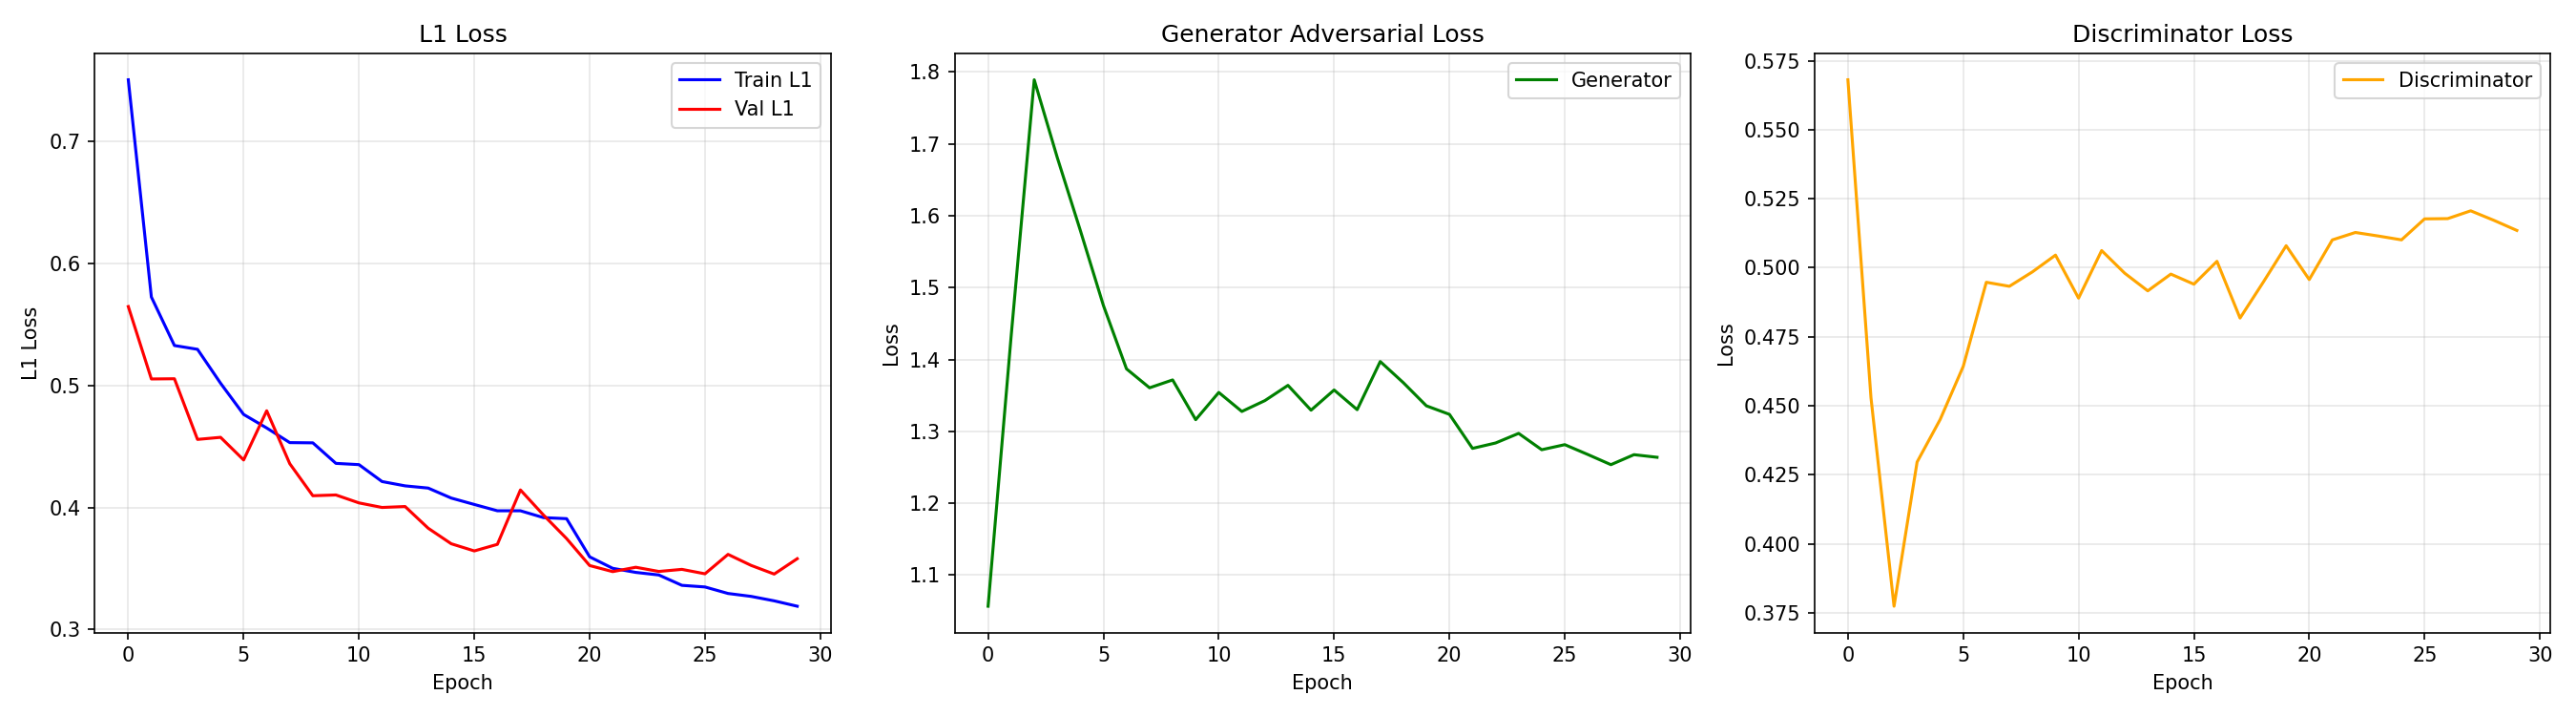

## 19. Load Trained Models for Inference

Load the best U-Net checkpoint and the fine-tuned HiFi-GAN weights.
This cell is useful when returning to the notebook after training -- it restores the full pipeline
without needing to re-run the training cells.


In [ ]:
import os
SAVE_DIR = '/content/drive/MyDrive/CelloProject'
BEST_PATH = os.path.join(SAVE_DIR, "cello_unet_v3_BEST.pth")

# Load fine-tuned HiFi-GAN
HIFIGAN_PATH = os.path.join(SAVE_DIR, "hifigan_cello_finetuned.pth")
if os.path.exists(HIFIGAN_PATH):
    G.load_state_dict(torch.load(HIFIGAN_PATH, map_location=device))
    G.eval()
    print("✅ Loaded fine-tuned HiFi-GAN")

# Load best U-Net
ckpt = torch.load(BEST_PATH, map_location=device)
unet.load_state_dict(ckpt["model_state_dict"])
unet.eval()
print(f"✅ Loaded U-Net from epoch {ckpt['epoch']} (val_loss: {ckpt['val_loss']:.4f})")

✅ Loaded fine-tuned HiFi-GAN
✅ Loaded U-Net from epoch 29 (val_loss: 0.3455)


## 20. Reload MAESTRO Dataset & Train/Val Split

Re-download the MAESTRO dataset if needed (e.g., after a session restart) and recreate
the same deterministic 90/10 train/validation split (seed=42) used during training.
This ensures we test on files the model has never seen during training.


In [ ]:
import os, glob, random

# Download MAESTRO if needed
if not os.path.exists('maestro-v3.0.0-midi.zip'):
    !wget -q https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip
    !unzip -q maestro-v3.0.0-midi.zip

midi_files = glob.glob("maestro-v3.0.0/**/*.midi", recursive=True) + \
             glob.glob("maestro-v3.0.0/**/*.mid", recursive=True)
print(f"Found {len(midi_files)} MIDI files")

# Same split as training
rng = random.Random(42)
files = list(midi_files)
rng.shuffle(files)
split = int(0.9 * len(files))
train_midis = files[:split]
val_midis = files[split:]
print(f"✅ Split: train={len(train_midis)} val={len(val_midis)}")

Found 1276 MIDI files
✅ Split: train=1148 val=128


## 21. Define Melody Extraction Function

Redefine the `extract_melody()` function for inference use.

This function takes a list of (possibly polyphonic) MIDI notes and returns a **monophonic melody**
by keeping only the highest-pitched note at each 10ms time step. The result is a sequence of
non-overlapping notes suitable for cello synthesis.


In [ ]:
import pretty_midi
import numpy as np

def extract_melody(notes, crop_sec, resolution=0.01):
    if len(notes) == 0:
        return []
    steps = int(crop_sec / resolution)
    melody_pitch = np.full(steps, -1, dtype=int)
    melody_vel = np.full(steps, 0, dtype=int)
    for note in notes:
        s = max(0, min(int(note.start / resolution), steps))
        e = max(0, min(int(note.end / resolution), steps))
        for t in range(s, e):
            if note.pitch > melody_pitch[t]:
                melody_pitch[t] = note.pitch
                melody_vel[t] = note.velocity
    melody_notes = []
    current_pitch = -1
    current_vel = 0
    note_start = 0.0
    for t in range(steps):
        pitch = melody_pitch[t]
        if pitch != current_pitch:
            if current_pitch > 0:
                note_end = t * resolution
                if note_end > note_start:
                    melody_notes.append(pretty_midi.Note(
                        velocity=current_vel, pitch=current_pitch,
                        start=note_start, end=note_end))
            current_pitch = pitch
            current_vel = melody_vel[t]
            note_start = t * resolution
    if current_pitch > 0:
        note_end = steps * resolution
        if note_end > note_start:
            melody_notes.append(pretty_midi.Note(
                velocity=current_vel, pitch=current_pitch,
                start=note_start, end=note_end))
    return melody_notes

print("✅ extract_melody defined")

✅ extract_melody defined


## 22. Load Fine-Tuned HiFi-GAN

Load the cello-specific HiFi-GAN weights saved during Part A.5.
This ensures the vocoder is optimized for cello audio reconstruction.


In [ ]:
import os, torch
path = "/content/drive/MyDrive/CelloProject/hifigan_cello_finetuned.pth"
G.load_state_dict(torch.load(path, map_location=device))
G.eval()
print("✅ Fine-tuned HiFi-GAN loaded")

✅ Fine-tuned HiFi-GAN loaded


## 23. Full Inference Pipeline

Run the complete trained model on MAESTRO validation files (or custom MIDI).

### Inference Steps

1. Load a MIDI file and extract the monophonic melody
2. Synthesize sawtooth waves from the melody notes
3. Convert to mel spectrogram
4. **Overlap-add processing**: Split the mel into 128-frame chunks with 75% overlap (stride=32),
   run each through the U-Net, and blend with Hann windows for smooth transitions
5. Vocode the final mel spectrogram through HiFi-GAN

The overlap-add technique prevents audible seams between chunks and allows processing
of arbitrarily long audio sequences despite the U-Net fixed 128-frame input size.

Three audio outputs are provided for comparison:
- **Sawtooth input** (what the model receives)
- **FluidSynth cello** (ground truth reference)
- **U-Net + HiFi-GAN output** (our model synthesis)


In [ ]:
# =====================
# INFERENCE — Run trained model on MAESTRO or custom MIDI
# =====================

import torch
import torch.nn.functional as F
import numpy as np
from scipy import signal
from IPython.display import Audio, display
import pretty_midi
import random

# -----------------------
# Load best model
# -----------------------
unet.eval()
if os.path.exists(BEST_PATH):
    ckpt = torch.load(BEST_PATH, map_location=device)
    unet.load_state_dict(ckpt["model_state_dict"])
    print(f"✅ Loaded BEST model from epoch {ckpt['epoch']} (val_loss: {ckpt['val_loss']:.4f})")
else:
    print("⚠️ No BEST checkpoint found, using current weights")

# -----------------------
# Inference function with overlap-add
# -----------------------
def run_inference(midi_path, duration_sec=10.0, use_melody=True):
    """
    Run full inference pipeline:
    MIDI → melody extraction → sawtooth → mel → U-Net → mel → HiFi-GAN → audio

    Args:
        midi_path: path to MIDI file
        duration_sec: max duration in seconds
        use_melody: if True, extract monophonic melody (recommended for MAESTRO)
    """
    unet.eval()

    pm = pretty_midi.PrettyMIDI(midi_path)
    end_time = min(pm.get_end_time(), duration_sec)
    sr = h.sampling_rate
    audio_len = int(end_time * sr)

    if use_melody:
        # Collect all notes
        all_notes = []
        for inst in pm.instruments:
            if inst.is_drum:
                continue
            for n in inst.notes:
                if n.start < end_time:
                    all_notes.append(pretty_midi.Note(
                        velocity=n.velocity,
                        pitch=n.pitch,
                        start=n.start,
                        end=min(n.end, end_time)
                    ))

        # Extract melody
        melody_notes = extract_melody(all_notes, end_time)
        print(f"🎵 Extracted {len(melody_notes)} melody notes from {len(all_notes)} total notes")
    else:
        # Use all notes as-is (for monophonic MIDI like Bach)
        melody_notes = []
        for inst in pm.instruments:
            if not inst.is_drum:
                for n in inst.notes:
                    if n.start < end_time:
                        melody_notes.append(pretty_midi.Note(
                            velocity=n.velocity,
                            pitch=n.pitch,
                            start=n.start,
                            end=min(n.end, end_time)
                        ))
        print(f"🎵 Using {len(melody_notes)} notes directly (no melody extraction)")

    if len(melody_notes) == 0:
        print("❌ No notes found!")
        return None

    # --- Build sawtooth input ---
    t = np.arange(audio_len) / sr
    input_wav = np.zeros(audio_len, dtype=np.float32)

    for note in melody_notes:
        freq = 440.0 * (2.0 ** ((note.pitch - 69.0) / 12.0))
        s = int(note.start * sr)
        e = int(note.end * sr)
        note_len = max(0, e - s)
        if note_len <= 0 or s >= audio_len:
            continue
        note_len = min(note_len, audio_len - s)

        wave = 0.5 * signal.sawtooth(2 * np.pi * freq * t[:note_len]).astype(np.float32)
        env = np.ones(note_len, dtype=np.float32)
        fade = min(200, note_len // 2)
        if fade > 0:
            env[:fade] = np.linspace(0, 1, fade, dtype=np.float32)
            env[-fade:] = np.linspace(1, 0, fade, dtype=np.float32)
        input_wav[s:s+note_len] += wave * env

    # --- Build cello target via FluidSynth ---
    pm_target = pretty_midi.PrettyMIDI()
    inst = pretty_midi.Instrument(program=42, is_drum=False)
    inst.notes = melody_notes
    pm_target.instruments.append(inst)
    target_wav = pm_target.fluidsynth(fs=sr, sf2_path=sf2_path).astype(np.float32)
    target_wav = target_wav[:audio_len]

    # --- Normalize ---
    input_wav = prep_audio_np(input_wav)
    target_wav = prep_audio_np(target_wav)

    # --- Convert to mel ---
    mel_total = audio_to_mel_hifigan(input_wav)  # [1, 80, T]

    # --- Overlap-add inference ---
    T = mel_total.shape[-1]
    CHUNK_SIZE = 128
    STRIDE = 32  # 75% overlap for smooth output

    output_mel = torch.zeros_like(mel_total).cpu()
    count_mask = torch.zeros_like(mel_total).cpu()
    window = torch.hann_window(CHUNK_SIZE).view(1, 1, -1)

    print(f"🧠 Processing {T} mel frames with overlap-add...")

    with torch.no_grad():
        for i in range(0, T - CHUNK_SIZE + 1, STRIDE):
            chunk = mel_total[:, :, i:i+CHUNK_SIZE]
            x = chunk.unsqueeze(1).to(device)  # [1, 1, 80, 128]
            pred = unet(x).squeeze(1).cpu()     # [1, 80, 128]
            output_mel[:, :, i:i+CHUNK_SIZE] += pred * window
            count_mask[:, :, i:i+CHUNK_SIZE] += window

        # Handle the tail
        if T > CHUNK_SIZE:
            last_chunk = mel_total[:, :, -CHUNK_SIZE:]
            pred = unet(last_chunk.unsqueeze(1).to(device)).squeeze(1).cpu()
            output_mel[:, :, -CHUNK_SIZE:] += pred * window
            count_mask[:, :, -CHUNK_SIZE:] += window

    # Normalize overlap
    final_mel = output_mel / (count_mask + 1e-8)

    # Silence the tail to avoid noise
    final_mel[:, :, -5:] = -11.5

    # --- Vocode ---
    print("🔊 Synthesizing audio via HiFi-GAN...")
    final_audio = vocode_mel(final_mel)

    # --- Display ---
    print("\n" + "="*50)
    print(f"  📄 {os.path.basename(midi_path)} ({end_time:.1f}s)")
    print("="*50)

    print("\n🎧 1. INPUT (Sawtooth)")
    display(Audio(input_wav, rate=sr))

    print("\n🎧 2. TARGET (FluidSynth Cello)")
    display(Audio(target_wav, rate=sr))

    print("\n🎧 3. OUTPUT (U-Net + HiFi-GAN)")
    display(Audio(final_audio, rate=sr))

    return final_audio

# =====================
# RUN INFERENCE
# =====================

# --- Option 1: Random MAESTRO file ---
print("🎻 Testing on random MAESTRO validation file:\n")
test_midi = random.choice(val_midis)
run_inference(test_midi, duration_sec=10.0, use_melody=True)

# --- Option 2: Try multiple files ---
# print("\n\n" + "="*60)
# print("  Testing on 3 random MAESTRO files")
# print("="*60)
# for i in range(3):
#     test_midi = random.choice(val_midis)
#     print(f"\n--- File {i+1} ---")
#     run_inference(test_midi, duration_sec=8.0, use_melody=True)

# --- Option 3: Custom MIDI (like Bach) ---
# run_inference("bach_high.mid", duration_sec=15.0, use_melody=False)


✅ Loaded BEST model from epoch 29 (val_loss: 0.3455)
🎻 Testing on random MAESTRO validation file:

🎵 Extracted 29 melody notes from 22 total notes


/tmp/ipython-input-4083921734.py:107: DeprecationWarning: The parameter 'sf2_path' is deprecated, please use 'synthesizer' instead.
  target_wav = pm_target.fluidsynth(fs=sr, sf2_path=sf2_path).astype(np.float32)


🧠 Processing 861 mel frames with overlap-add...
🔊 Synthesizing audio via HiFi-GAN...

  📄 MIDI-Unprocessed_R1_D2-13-20_mid--AUDIO-from_mp3_15_R1_2015_wav--1.midi (10.0s)

🎧 1. INPUT (Sawtooth)



🎧 2. TARGET (FluidSynth Cello)



🎧 3. OUTPUT (U-Net + HiFi-GAN)


array([ 1.6197170e-01,  1.9140778e-02, -4.6564829e-02, ...,
       -2.0080806e-05, -2.0706429e-06, -2.1908250e-05], dtype=float32)

## 24. Spectrogram Visualization & Comparison

Visual comparison of the model output against the target:

1. **Target mel spectrogram**: What the cello should look like in mel space
2. **Predicted mel spectrogram**: What the U-Net actually produces
3. **Difference map**: Absolute error between target and prediction

Lower mean difference indicates better mel prediction accuracy.
The visualization helps identify specific frequency regions or time segments where the model struggles.


/tmp/ipython-input-1587238930.py:51: DeprecationWarning: The parameter 'sf2_path' is deprecated, please use 'synthesizer' instead.
  target_wav = pm_tgt.fluidsynth(fs=sr, sf2_path=sf2_path).astype(np.float32)


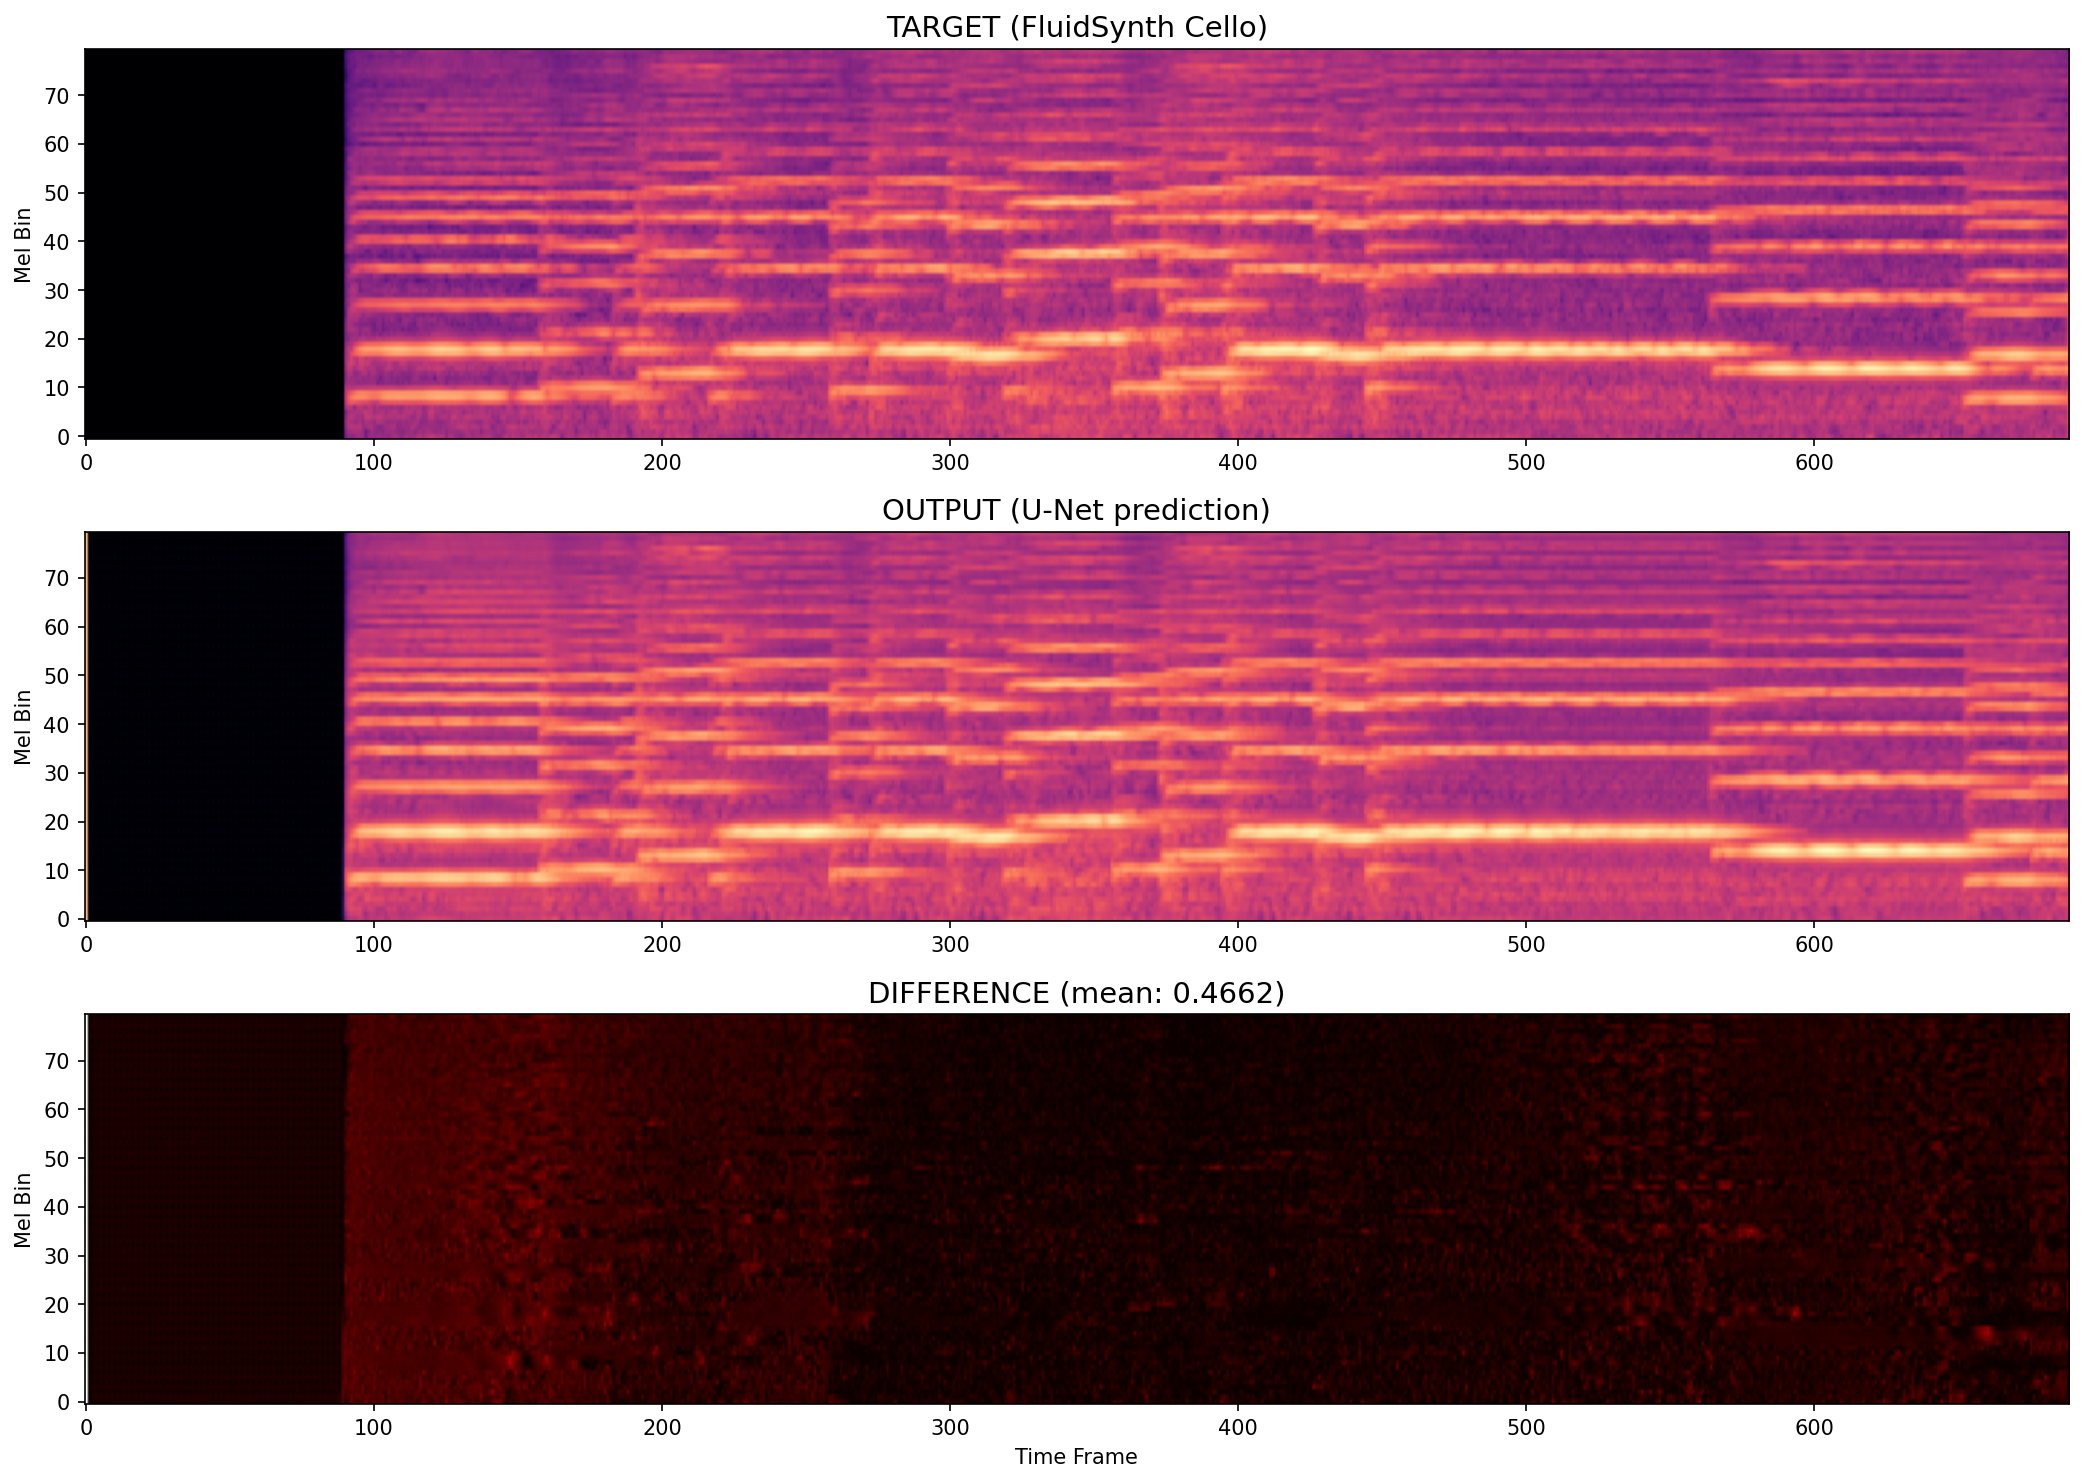

✅ Done


In [ ]:
%matplotlib inline
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import random
from scipy import signal
from IPython.display import Image, display as ipy_display

# Generate fresh sample
test_midi = random.cho or ice(val_midis)
pm = pretty_midi.PrettyMIDI(test_midi)
end_time = min(pm.get_end_time(), 8.0)
sr = h.sampling_rate

# Extract melody
all_notes = []
for inst in pm.instruments:
    if not inst.is_drum:
        for n in inst.notes:
            if n.start < end_time:
                all_notes.append(pretty_midi.Note(
                    velocity=n.velocity, pitch=n.pitch,
                    start=n.start, end=min(n.end, end_time)))

melody_notes = extract_melody(all_notes, end_time)

# Build sawtooth
audio_len = int(end_time * sr)
t = np.arange(audio_len) / sr
input_wav = np.zeros(audio_len, dtype=np.float32)
for note in melody_notes:
    freq = 440.0 * (2.0 ** ((note.pitch - 69.0) / 12.0))
    s = int(note.start * sr)
    e = int(note.end * sr)
    n = max(0, min(e - s, audio_len - s))
    if n > 0 and s < audio_len:
        wave = 0.5 * signal.sawtooth(2 * np.pi * freq * t[:n]).astype(np.float32)
        env = np.ones(n, dtype=np.float32)
        fade = min(200, n // 2)
        if fade > 0:
            env[:fade] = np.linspace(0, 1, fade)
            env[-fade:] = np.linspace(1, 0, fade)
        input_wav[s:s+n] += wave * env

# Build target
pm_tgt = pretty_midi.PrettyMIDI()
inst = pretty_midi.Instrument(program=42)
inst.notes = melody_notes
pm_tgt.instruments.append(inst)
target_wav = pm_tgt.fluidsynth(fs=sr, sf2_path=sf2_path).astype(np.float32)
target_wav = prep_audio_np(target_wav[:audio_len])
input_wav = prep_audio_np(input_wav)

# Get target mel
mel_target = audio_to_mel_hifigan(target_wav).cpu()

# Run U-Net with overlap-add
mel_in = audio_to_mel_hifigan(input_wav)
T = mel_in.shape[-1]
CHUNK = 128
STRIDE = 32
output_mel = torch.zeros_like(mel_in).cpu()
count_mask = torch.zeros_like(mel_in).cpu()
window = torch.hann_window(CHUNK).view(1, 1, -1)

unet.eval()
with torch.no_grad():
    for i in range(0, T - CHUNK + 1, STRIDE):
        chunk = mel_in[:, :, i:i+CHUNK]
        pred = unet(chunk.unsqueeze(1).to(device)).squeeze(1).cpu()
        output_mel[:, :, i:i+CHUNK] += pred * window
        count_mask[:, :, i:i+CHUNK] += window
    if T > CHUNK:
        pred = unet(mel_in[:, :, -CHUNK:].unsqueeze(1).to(device)).squeeze(1).cpu()
        output_mel[:, :, -CHUNK:] += pred * window
        count_mask[:, :, -CHUNK:] += window

final_mel = output_mel / (count_mask + 1e-8)

# Plot and save
min_t = min(mel_target.shape[-1], final_mel.shape[-1])

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].imshow(mel_target.squeeze().numpy()[:, :min_t], aspect='auto', origin='lower', cmap='magma')
axes[0].set_title('TARGET (FluidSynth Cello)', fontsize=14)
axes[0].set_ylabel('Mel Bin')

axes[1].imshow(final_mel.squeeze().numpy()[:, :min_t], aspect='auto', origin='lower', cmap='magma')
axes[1].set_title('OUTPUT (U-Net prediction)', fontsize=14)
axes[1].set_ylabel('Mel Bin')

diff = (mel_target[:,:,:min_t] - final_mel[:,:,:min_t]).abs()
axes[2].imshow(diff.squeeze().numpy(), aspect='auto', origin='lower', cmap='hot')
axes[2].set_title(f'DIFFERENCE (mean: {diff.mean():.4f})', fontsize=14)
axes[2].set_ylabel('Mel Bin')
axes[2].set_xlabel('Time Frame')

plt.tight_layout()
plt.savefig("/content/spectrogram_compare.png", dpi=150, bbox_inches='tight')
plt.close()

# Force display
ipy_display(Image("/content/spectrogram_compare.png"))
print("✅ Done")

## 26. Conclusions

### Summary

This project presented a complete neural timbre-transfer pipeline that converts sawtooth wave audio into realistic cello sounds. The system combines three learned components: (1) a **U-Net** that translates sawtooth mel spectrograms into cello-like mel spectrograms, (2) a **PatchGAN discriminator** that provides adversarial sharpness supervision, and (3) a **HiFi-GAN vocoder** fine-tuned on cello audio that synthesises the final waveform.

Training on pre-rendered pairs derived from the **MAESTRO v3.0.0** dataset (over 6,000 training examples from ~1,200 classical piano MIDI files) demonstrated that the mel spectrogram domain provides a compact, learnable intermediate representation that successfully decouples timbral transformation from pitch and timing preservation.


### Limitations

1. **SoundFont target quality**: FluidSynth with a MIDI SoundFont produces only a synthetic approximation of real cello playing; the model learns the characteristics of this approximation, not a live instrument recording.
2. **Monophonic constraint**: Melody extraction limits inputs to single-voice sequences. Polyphonic cello playing (double-stops) is not supported.
3. **Fixed segment length**: The U-Net processes fixed 128-frame mel windows; the overlap-add scheme mitigates boundary artefacts but does not eliminate them entirely.
4. **Limited compute**: Training was conducted on Colab with a single GPU, limiting the number of epochs and dataset scale relative to production neural audio systems.

### Future Work

- **Real cello recordings**: Replace FluidSynth targets with a dataset of real cello recordings (e.g., the URMP dataset) for higher-fidelity supervision.
- **Subjective listening study**: Conduct a Mean Opinion Score (MOS) listening test with human participants to complement the automated metrics.
- **Streaming inference**: Replace the overlap-add U-Net with an autoregressive architecture (e.g., WaveNet or SoundStream) for real-time synthesis.
- **Multi-instrument transfer**: Extend the pipeline to other orchestral instruments (violin, viola, bass) using a shared encoder with instrument-conditioning.
- **Expressive control**: Incorporate velocity and articulation signals to generate dynamically expressive cello phrases beyond uniform mezzo-forte.

### References

- Engel, J. et al. (2020). DDSP: Differentiable Digital Signal Processing. *ICLR 2020*.
- Goodfellow, I. et al. (2014). Generative Adversarial Networks. *NeurIPS 2014*.
- Isola, P. et al. (2017). Image-to-Image Translation with Conditional Adversarial Networks. *CVPR 2017*.
- Jansson, A. et al. (2017). Singing Voice Separation with Deep U-Net Convolutional Networks. *ISMIR 2017*.
- Kong, J. et al. (2020). HiFi-GAN: Generative Adversarial Networks for Efficient and High Fidelity Speech Synthesis. *NeurIPS 2020*.
- Le Roux, J. et al. (2019). SDR -- Half-Baked or Well Done? *ICASSP 2019*.
- Mor, N. et al. (2019). A Universal Music Translation Network. *ICLR 2019*.
- O'Shaughnessy, D. (1987). *Speech Communication: Human and Machine*. Addison-Wesley.
- Ribeiro, F. et al. (2011). CROWDMOS: An Approach for Crowdsourcing Mean Opinion Score Studies. *ICASSP 2011*.
- Ronneberger, O. et al. (2015). U-Net: Convolutional Networks for Biomedical Image Segmentation. *MICCAI 2015*.
- Toda, T. et al. (2007). Voice Conversion Based on Maximum-Likelihood Estimation of Spectral Parameter Trajectory. *IEEE Trans. ASLP 2007*.
- Yamamoto, R. et al. (2020). Parallel WaveGAN. *ICASSP 2020*.
